# BÀI TẬP LỚN — NỀN TẢNG LẬP TRÌNH CHO PHÂN TÍCH VÀ TRỰC QUAN DỮ LIỆU
**Học kỳ 261 – Năm học 2026–2027 · Giảng viên: Lê Thành Sách**

## BÀI 2 — DỮ LIỆU VĂN BẢN (TEXT): PHÂN LOẠI CẢM XÚC ĐÁNH GIÁ SẢN PHẨM AMAZON
- **Nhóm:** `<Tên nhóm>` — **Thành viên:** `<Họ tên – MSSV – vai trò>`

**Bài toán:** phân loại đa lớp (3 lớp) — dự đoán cảm xúc của một đánh giá sản phẩm Amazon (tiếng Anh) là
**Tiêu cực / Trung tính / Tích cực**, để bộ phận chăm sóc khách hàng nhận diện sớm các đánh giá cần phản hồi.

**Câu hỏi chính của bài:**
1. Những từ và đặc điểm nào phân biệt đánh giá tiêu cực, trung tính và tích cực?
2. Dữ liệu **mất cân bằng nặng** (~90% tích cực) ảnh hưởng thế nào, và **xử lý mất cân bằng giúp bắt thêm được bao nhiêu đánh giá tiêu cực / trung tính**?

**Quy trình:** EDA → làm sạch văn bản và tiền xử lý trong Pipeline (chống rò rỉ dữ liệu) → so sánh baseline với 3 thuật toán
(MultinomialNB, Logistic Regression, LinearSVC) → tinh chỉnh siêu tham số bằng GridSearchCV → đánh giá một lần trên tập Test →
phân tích lỗi, kiểm tra trên tập ngoài và hàm suy luận `predict_sample`.

## 0. CÀI ĐẶT MÔI TRƯỜNG

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
CLASS_NAMES = {0: 'Tiêu cực', 1: 'Trung tính', 2: 'Tích cực'}
CLASS_COLORS = {0: '#DD5145', 1: '#E0B341', 2: '#55A868'}
print('Môi trường đã sẵn sàng!')

Môi trường đã sẵn sàng!


## 1. MÔ TẢ TẬP DỮ LIỆU VÀ KHÁM PHÁ (EDA)

**Nguồn:** bộ đánh giá sản phẩm Amazon (chủ yếu là thẻ nhớ SD/microSD, đánh giá từ 01/2012 đến 12/2014; xem bằng chứng ở 1.9), file `amazon_reviews.csv`
gồm **4,915 đánh giá × 12 cột**. Mỗi dòng có điểm sao `overall` (1–5) do chính người mua chấm và nội dung `reviewText`.
**Link nguồn:** https://www.kaggle.com/datasets/tarkkaanko/amazon.

**Cách gán nhãn cảm xúc** (theo gợi ý của đề: Tích cực / Trung tính / Tiêu cực):

| Điểm sao `overall` | Nhãn | Mã |
|---|---|---|
| 1 – 2 sao | Tiêu cực (Negative) | 0 |
| 3 sao | Trung tính (Neutral) | 1 |
| 4 – 5 sao | Tích cực (Positive) | 2 |

> ⚠️ **Lưu ý minh bạch:** đây là bộ dữ liệu công khai có sẵn, **nhóm không tự crawl**. Nhãn cảm xúc suy ra từ điểm sao, nên có nhiễu
> (người dùng có thể viết nội dung tiêu cực nhưng vẫn chấm 3–4 sao). Phần phân tích lỗi (4.4) sẽ kiểm tra điều này.
> Ngoài ra nhóm dùng thêm file `external_test.jsonl` (5,000 đánh giá, nhãn 0–4) **chỉ làm tập kiểm tra ngoài** ở mục 4.5, không dùng để huấn luyện.

### 1.1. Tải dữ liệu

In [2]:
GITHUB_RAW_BASE = 'https://raw.githubusercontent.com/perckgg/NTLT/main/02_Text/data/text'
DATA_FILE = 'amazon_reviews.csv'
EXTERNAL_FILE = 'external_test.jsonl'
LOCAL_DIRS = ['data/text', '../data/text', '/content/data/text', '/content']


def locate(filename):
    # Trả về đường dẫn local nếu có, ngược lại trả về URL trên GitHub.
    for d in LOCAL_DIRS:
        p = Path(d) / filename
        if p.exists():
            return str(p)
    return f'{GITHUB_RAW_BASE}/{filename}'


def read_csv_safe(filename):
    path = locate(filename)
    try:
        return pd.read_csv(path), path
    except Exception as err:
        raise FileNotFoundError(
            f'Không đọc được {filename} ({path}). Hãy upload file vào /content hoặc push thư mục 02_Text/data/text '
            f'lên GitHub và chỉnh GITHUB_RAW_BASE. Lỗi gốc: {err}')


def read_jsonl_safe(filename):
    path = locate(filename)
    try:
        return pd.read_json(path, lines=True), path
    except Exception as err:
        raise FileNotFoundError(f'Không đọc được {filename} ({path}). Lỗi gốc: {err}')


raw, data_path = read_csv_safe(DATA_FILE)
print(f'Nguồn dữ liệu: {data_path}')
print(f'Kích thước: {raw.shape[0]:,} dòng × {raw.shape[1]} cột')
display(raw.head(3))

Nguồn dữ liệu: ../data/text/amazon_reviews.csv
Kích thước: 4,915 dòng × 12 cột


,Unnamed: 0,reviewerName,overall,reviewText,reviewTime,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound
0,0,NaN,4.000,No issues.,2014-07-23,138,0,0,0,0,0.000,0.000
1,1,0mie,5.000,"Purchased this for my device, it worked as advertised. You can never have too much phone memory, since I download a ...",2013-10-25,409,0,0,0,0,0.000,0.000
2,2,1K3,4.000,it works as expected. I should have sprung for the higher capacity. I think its made a bit cheesier than the earlie...,2012-12-23,715,0,0,0,0,0.000,0.000


### 1.2. Ý nghĩa các cột và kiểu dữ liệu

In [3]:
COLUMN_INFO = {
    'Unnamed: 0': 'Chỉ số dòng của file gốc (định danh, không mang thông tin)',
    'reviewerName': 'Tên người đánh giá (định danh, cardinality rất cao)',
    'overall': 'Điểm sao 1–5 do người mua chấm → dùng để gán nhãn cảm xúc',
    'reviewText': 'Nội dung đánh giá (tiếng Anh) → đặc trưng văn bản chính',
    'reviewTime': 'Ngày đăng đánh giá',
    'day_diff': 'Số ngày từ lúc đăng đánh giá đến ngày thu thập dữ liệu',
    'helpful_yes': 'Số người bình chọn "hữu ích"',
    'helpful_no': 'Số người bình chọn "không hữu ích"',
    'total_vote': 'Tổng số bình chọn (= helpful_yes + helpful_no)',
    'score_pos_neg_diff': 'helpful_yes − helpful_no (suy ra từ cột bình chọn)',
    'score_average_rating': 'helpful_yes / total_vote (suy ra từ cột bình chọn)',
    'wilson_lower_bound': 'Cận dưới Wilson của tỉ lệ hữu ích (suy ra từ cột bình chọn)',
}
info = pd.DataFrame({'Kiểu dữ liệu': raw.dtypes.astype(str), 'Số giá trị khác nhau': raw.nunique(),
                     'Ý nghĩa': pd.Series(COLUMN_INFO)})
display(info)

,Kiểu dữ liệu,Số giá trị khác nhau,Ý nghĩa
Unnamed: 0,int64,4915,"Chỉ số dòng của file gốc (định danh, không mang thông tin)"
reviewerName,str,4594,"Tên người đánh giá (định danh, cardinality rất cao)"
overall,float64,5,Điểm sao 1–5 do người mua chấm → dùng để gán nhãn cảm xúc
reviewText,str,4912,Nội dung đánh giá (tiếng Anh) → đặc trưng văn bản chính
reviewTime,str,690,Ngày đăng đánh giá
day_diff,int64,690,Số ngày từ lúc đăng đánh giá đến ngày thu thập dữ liệu
helpful_yes,int64,23,"Số người bình chọn ""hữu ích"""
helpful_no,int64,17,"Số người bình chọn ""không hữu ích"""
total_vote,int64,26,Tổng số bình chọn (= helpful_yes + helpful_no)
score_pos_neg_diff,int64,27,helpful_yes − helpful_no (suy ra từ cột bình chọn)


### 1.3. Tổng quan nhanh (KPI)
Các chỉ số tổng quan giống bảng điều khiển phân tích đánh giá thương mại điện tử: số đánh giá, điểm sao trung bình,
độ dài đánh giá trung bình, số ngày kể từ khi đăng và số phiếu "hữu ích".

In [4]:
kpi = pd.Series({
    'Tổng số đánh giá': len(raw),
    'Điểm sao trung bình': raw['overall'].mean(),
    'Độ dài trung bình (số từ)': raw['reviewText'].dropna().str.split().str.len().mean(),
    'Số ngày kể từ khi đăng (trung bình)': raw['day_diff'].mean(),
    'Tổng phiếu "hữu ích"': raw['helpful_yes'].sum(),
    '% đánh giá có người bình chọn': (raw['total_vote'] > 0).mean() * 100,
})
display(kpi.to_frame('Giá trị').style.format('{:,.2f}'))

,Giá trị
Tổng số đánh giá,"4,915.00"
Điểm sao trung bình,4.59
Độ dài trung bình (số từ),50.45
Số ngày kể từ khi đăng (trung bình),437.37
"Tổng phiếu ""hữu ích""","6,444.00"
% đánh giá có người bình chọn,11.29


### 1.4. Giá trị thiếu (Missing values)

In [5]:
miss = pd.DataFrame({'Số ô thiếu': raw.isna().sum(), 'Tỉ lệ (%)': raw.isna().mean() * 100})
miss['Mức độ'] = pd.cut(miss['Tỉ lệ (%)'], [-0.001, 0, 5, 20, 100], labels=['Không thiếu', 'Thấp (<5%)', 'Trung bình (5–20%)', 'Cao (>20%)'])
display(miss)
print(f'Số dòng có ít nhất 1 ô thiếu: {raw.isna().any(axis=1).sum()} ({raw.isna().any(axis=1).mean():.2%})')
print('Dòng thiếu reviewText:')
display(raw[raw['reviewText'].isna()])
print(f"Số đánh giá có nội dung trùng lặp: {raw['reviewText'].dropna().duplicated().sum()}")

,Số ô thiếu,Tỉ lệ (%),Mức độ
Unnamed: 0,0,0.000,Không thiếu
reviewerName,1,0.020,Thấp (<5%)
overall,0,0.000,Không thiếu
reviewText,1,0.020,Thấp (<5%)
reviewTime,0,0.000,Không thiếu
day_diff,0,0.000,Không thiếu
helpful_yes,0,0.000,Không thiếu
helpful_no,0,0.000,Không thiếu
total_vote,0,0.000,Không thiếu
score_pos_neg_diff,0,0.000,Không thiếu


Số dòng có ít nhất 1 ô thiếu: 2 (0.04%)
Dòng thiếu reviewText:


,Unnamed: 0,reviewerName,overall,reviewText,reviewTime,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound
125,125,Alexander Stevens,5.000,NaN,2012-08-21,839,2,1,3,1,0.667,0.208


Số đánh giá có nội dung trùng lặp: 2


> **Nhận xét:**
> - Dữ liệu gần như đầy đủ: chỉ **2/4,915 dòng (0.04%)** có ô thiếu: 1 dòng thiếu `reviewText` và 1 dòng thiếu `reviewerName` (cột định danh, sẽ bị loại).
> - Dòng thiếu `reviewText` không thể phân loại cảm xúc nên sẽ bị **xóa** (không điền bù).
> - Có **2 đánh giá trùng nội dung** (`reviewText` giống hệt) → xóa bản lặp để cùng một câu không rơi vào cả Train lẫn Test.

### 1.5. Phân bố biến mục tiêu

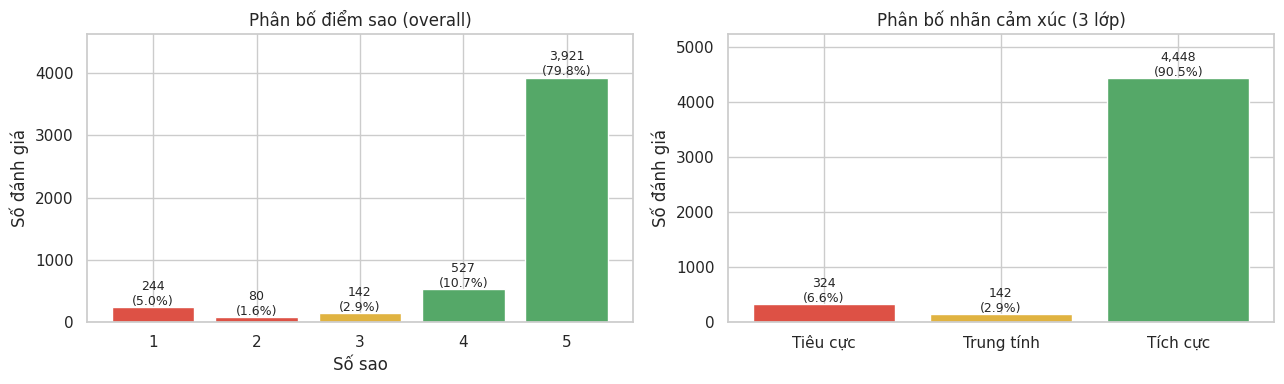

Tỉ lệ lớp đa số / lớp thiểu số = 31.3 : 1
Mô hình luôn đoán "Tích cực" đã đạt Accuracy = 0.905 nhưng F1 trung bình các lớp chỉ = 0.317


In [6]:
def rating_to_label(r):
    return 0 if r <= 2 else (1 if r == 3 else 2)


df_eda = raw.dropna(subset=['reviewText']).copy()
df_eda['label'] = df_eda['overall'].map(rating_to_label)
df_eda['word_count'] = df_eda['reviewText'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
star = df_eda['overall'].value_counts().sort_index()
axes[0].bar(star.index.astype(int), star.values, color=['#DD5145', '#DD5145', '#E0B341', '#55A868', '#55A868'])
for x, v in zip(star.index.astype(int), star.values):
    axes[0].text(x, v + 40, f'{v:,}\n({v / len(df_eda):.1%})', ha='center', fontsize=9)
axes[0].set(title='Phân bố điểm sao (overall)', xlabel='Số sao', ylabel='Số đánh giá', ylim=(0, star.max() * 1.18))

lab = df_eda['label'].value_counts().sort_index()
axes[1].bar([CLASS_NAMES[i] for i in lab.index], lab.values, color=[CLASS_COLORS[i] for i in lab.index])
for x, v in enumerate(lab.values):
    axes[1].text(x, v + 40, f'{v:,}\n({v / len(df_eda):.1%})', ha='center', fontsize=9)
axes[1].set(title='Phân bố nhãn cảm xúc (3 lớp)', ylabel='Số đánh giá', ylim=(0, lab.max() * 1.18))
plt.tight_layout(); plt.show()

ratio = lab.max() / lab.min()
print(f'Tỉ lệ lớp đa số / lớp thiểu số = {ratio:.1f} : 1')
print(f'Mô hình luôn đoán "Tích cực" đã đạt Accuracy = {lab.max() / lab.sum():.3f} nhưng F1 trung bình các lớp chỉ = '
      f'{f1_score(df_eda["label"], np.full(len(df_eda), 2), average="macro"):.3f}')

> **Nhận xét:**
> - Điểm sao lệch hẳn về cao: **4–5 sao chiếm 4,448/4,914 (90.5%)**, 1–2 sao chỉ 324 (6.6%), 3 sao chỉ 142 (2.9%).
> - Tỉ lệ lớp đa số / thiểu số = **31.3 : 1**. Một mô hình "luôn đoán Tích cực" đạt Accuracy **0.905** nhưng F1 macro chỉ **0.317** → Accuracy không đủ để đánh giá; F1 macro được chọn làm thước đo chính.
> - Lớp **Trung tính chỉ có 142 mẫu** (khoảng 99 mẫu ở Train, 21–22 mẫu ở Validation/Test), nên mọi chỉ số của lớp này rất nhiễu.

### 1.6. Phân phối độ dài đánh giá

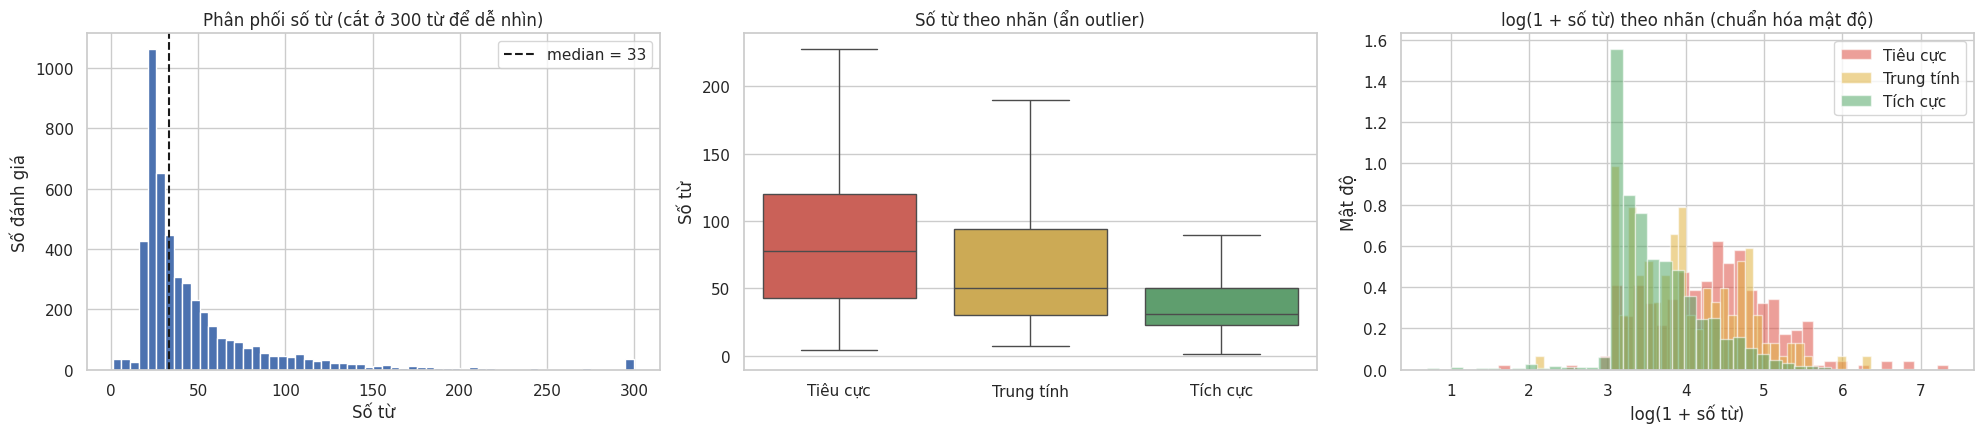

Độ lệch (skewness) của số từ: 8.48


,count,mean,median,max
label,,,,
Tiêu cực,324,106.478,78.000,1554
Trung tính,142,73.254,50.000,580
Tích cực,4448,45.644,31.000,1037


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4.5))
axes[0].hist(df_eda['word_count'].clip(upper=300), bins=60, color='#4C72B0')
axes[0].set(title='Phân phối số từ (cắt ở 300 từ để dễ nhìn)', xlabel='Số từ', ylabel='Số đánh giá')
axes[0].axvline(df_eda['word_count'].median(), c='k', ls='--', label=f"median = {df_eda['word_count'].median():.0f}")
axes[0].legend()

sns.boxplot(data=df_eda, x='label', y='word_count', palette=[CLASS_COLORS[i] for i in range(3)], order=[0, 1, 2], ax=axes[1], showfliers=False)
axes[1].set_xticklabels([CLASS_NAMES[i] for i in range(3)])
axes[1].set(title='Số từ theo nhãn (ẩn outlier)', xlabel='', ylabel='Số từ')

for k in range(3):
    axes[2].hist(np.log1p(df_eda.loc[df_eda['label'] == k, 'word_count']), bins=40, alpha=.55, density=True,
                 color=CLASS_COLORS[k], label=CLASS_NAMES[k])
axes[2].set(title='log(1 + số từ) theo nhãn (chuẩn hóa mật độ)', xlabel='log(1 + số từ)', ylabel='Mật độ')
axes[2].legend()
plt.tight_layout(); plt.show()

print(f"Độ lệch (skewness) của số từ: {df_eda['word_count'].skew():.2f}")
display(df_eda.groupby('label')['word_count'].agg(['count', 'mean', 'median', 'max']).rename(index=CLASS_NAMES))

> **Nhận xét:**
> - Độ dài rất lệch phải (skewness = **8.48**): trung bình 50 từ nhưng dài nhất 1,554 từ.
> - Người viết đánh giá **tiêu cực viết dài hơn rõ rệt**: trung bình 106.5 từ (median 78) so với 73.3 (median 50) ở Trung tính và 45.6 (median 31) ở Tích cực, tức dài gấp khoảng 2.3–2.5 lần lớp Tích cực.
> - Độ dài vì vậy có tín hiệu, nhưng hai phân phối chồng lấn nhiều (xem biểu đồ log), không đủ để tự phân loại. Dùng `log1p` khi đưa vào mô hình để nén đuôi phải.

### 1.7. Ma trận tương quan (Spearman) giữa các đặc trưng số
Dùng hệ số **Spearman** vì các cột bình chọn và độ dài lệch phải mạnh (phụ thuộc thứ hạng, không phụ thuộc giá trị cực đoan).

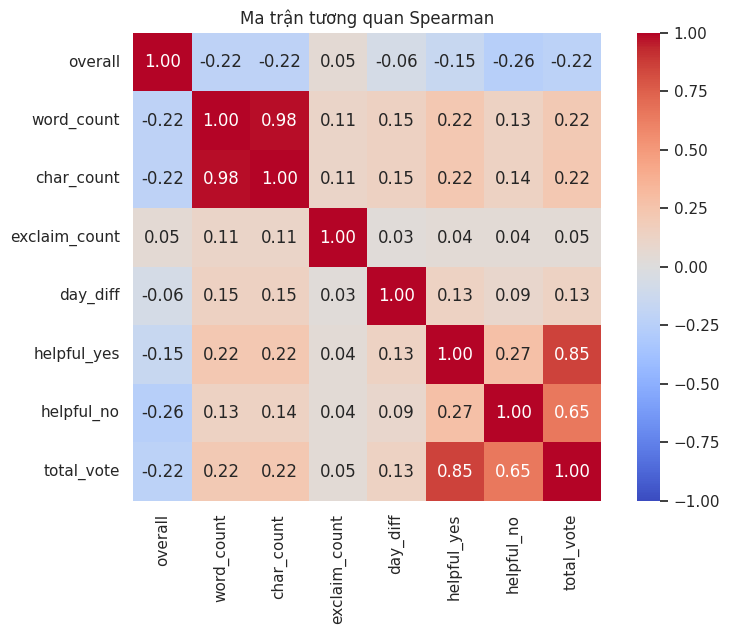

Các cặp tương quan mạnh nhất (|ρ|):


,,Spearman ρ
word_count,char_count,0.979
helpful_yes,total_vote,0.853
helpful_no,total_vote,0.653
helpful_yes,helpful_no,0.274


Tương quan của overall với các cột còn lại:


,ρ
helpful_no,-0.256
total_vote,-0.222
char_count,-0.218
word_count,-0.216
helpful_yes,-0.150
day_diff,-0.063
exclaim_count,0.054


In [8]:
df_eda['char_count'] = df_eda['reviewText'].str.len()
df_eda['exclaim_count'] = df_eda['reviewText'].str.count('!')
NUM_EDA = ['overall', 'word_count', 'char_count', 'exclaim_count', 'day_diff', 'helpful_yes', 'helpful_no', 'total_vote']
corr = df_eda[NUM_EDA].corr(method='spearman')
plt.figure(figsize=(8.5, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True)
plt.title('Ma trận tương quan Spearman'); plt.tight_layout(); plt.show()

pairs = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack().sort_values(key=abs, ascending=False)
print('Các cặp tương quan mạnh nhất (|ρ|):'); display(pairs.head(4).to_frame('Spearman ρ'))
print('Tương quan của overall với các cột còn lại:'); display(corr['overall'].drop('overall').sort_values().to_frame('ρ'))

> **Nhận xét:**
> - `word_count` và `char_count` gần như trùng nhau (ρ = **0.979**); `helpful_yes`/`helpful_no` đều tương quan mạnh với `total_vote` (0.853 và 0.653) → các cột này mang thông tin chồng lấn.
> - `overall` chỉ tương quan **yếu** với các cột còn lại, mạnh nhất cũng chỉ |ρ| = 0.256 (`helpful_no`, âm), rồi `total_vote` (−0.222), `char_count` (−0.218), `word_count` (−0.216). Đánh giá điểm thấp thường dài hơn và nhận nhiều bình chọn hơn.
> - `exclaim_count` (+0.054) và `day_diff` (−0.063) gần như không liên quan. Không đặc trưng số nào đủ mạnh để đoán cảm xúc → thông tin chính nằm ở **nội dung văn bản**.

### 1.8. Giá trị ngoại lai (Outliers) bằng IQR

,Q1,Q3,IQR,Ngưỡng trên,Số outlier,% outlier,Max,Skew
Cột,,,,,,,,
word_count,23.000,55.000,32.000,103.000,452,9.198,1554,8.478
char_count,123.000,289.000,166.000,538.000,464,9.442,8638,8.774
exclaim_count,0.000,0.000,0.000,0.000,807,16.422,21,7.950
day_diff,281.000,601.000,320.000,"1,081.000",0,0.000,1064,0.142
helpful_yes,0.000,0.000,0.000,0.000,412,8.384,1952,40.235
helpful_no,0.000,0.000,0.000,0.000,240,4.884,183,33.181
total_vote,0.000,0.000,0.000,0.000,554,11.274,2020,39.361


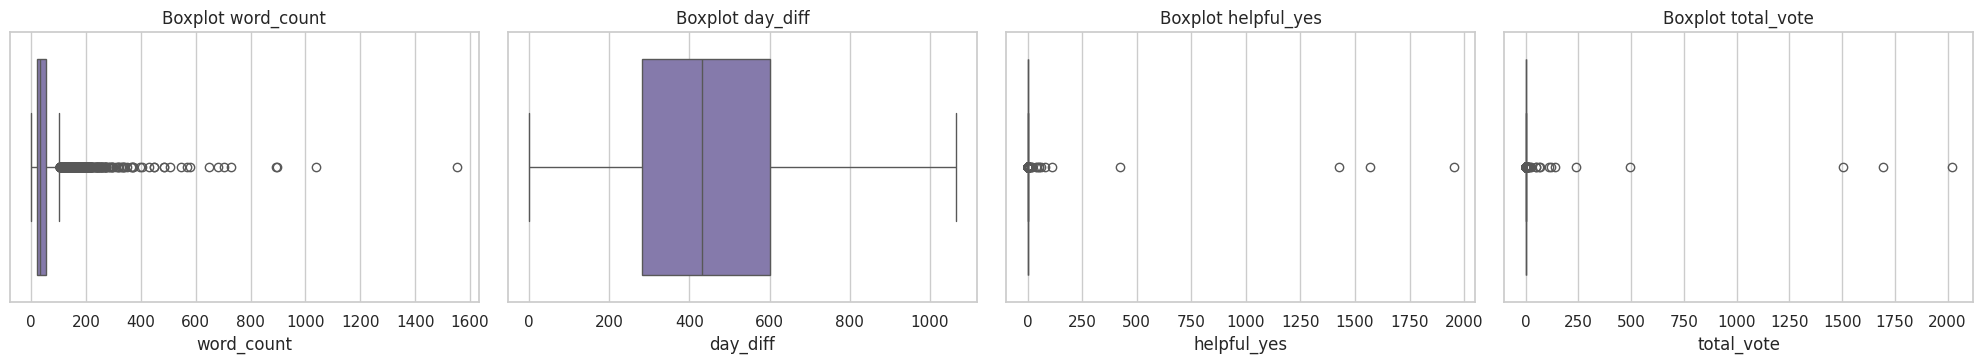

In [9]:
def iqr_table(frame, cols):
    rows = []
    for c in cols:
        q1, q3 = frame[c].quantile([.25, .75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = int(((frame[c] < lo) | (frame[c] > hi)).sum())
        rows.append({'Cột': c, 'Q1': q1, 'Q3': q3, 'IQR': iqr, 'Ngưỡng trên': hi, 'Số outlier': n_out,
                     '% outlier': n_out / len(frame) * 100, 'Max': frame[c].max(), 'Skew': frame[c].skew()})
    return pd.DataFrame(rows).set_index('Cột')


OUT_COLS = ['word_count', 'char_count', 'exclaim_count', 'day_diff', 'helpful_yes', 'helpful_no', 'total_vote']
display(iqr_table(df_eda, OUT_COLS))

fig, axes = plt.subplots(1, 4, figsize=(20, 3.8))
for ax, c in zip(axes, ['word_count', 'day_diff', 'helpful_yes', 'total_vote']):
    sns.boxplot(x=df_eda[c], ax=ax, color='#8172B3'); ax.set_title(f'Boxplot {c}')
plt.tight_layout(); plt.show()

> **Nhận xét:**
> - Các cột đếm có nhiều outlier theo IQR: `word_count` 452 (9.2%), `char_count` 464 (9.4%), `exclaim_count` 807 (16.4%), `helpful_yes` 412 (8.4%), `helpful_no` 240 (4.9%), `total_vote` 554 (11.3%).
> - Với 3 cột bình chọn, IQR = 0 vì hơn 75% đánh giá không có phiếu nào, nên mọi giá trị khác 0 đều bị tính là outlier (skewness 30–40).
> - Đây là **giá trị thật** (đánh giá dài, đánh giá được nhiều người bình chọn), không phải lỗi nhập liệu → **không xóa**, mà nén bằng `log1p` ở bước tiền xử lý. `day_diff` không có outlier (skew = 0.14).

### 1.9. Quan hệ giữa cảm xúc và các đặc trưng khác

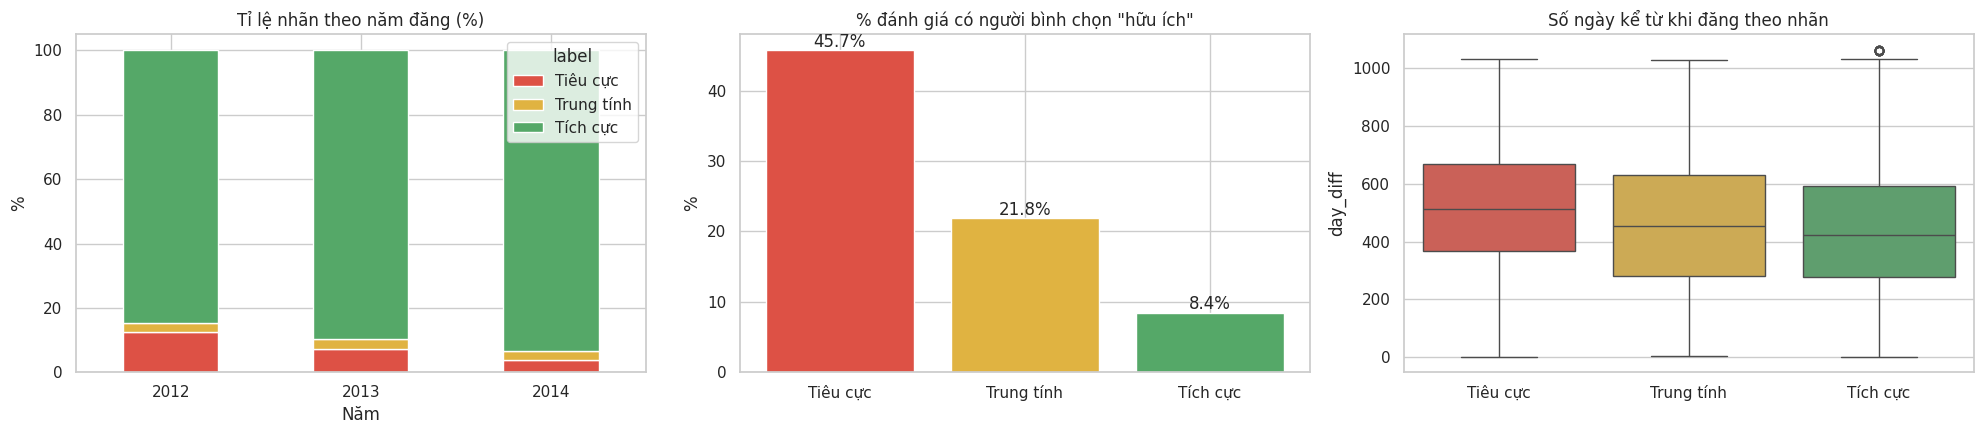

label,Tiêu cực,Trung tính,Tích cực
year,,,
2012,62,15,423
2013,195,82,2401
2014,67,45,1624


,votes_mean,helpful_yes_mean,exclaim_mean,day_diff_mean
label,,,,
Tiêu cực,7.963,6.812,0.312,514.235
Trung tính,0.542,0.352,0.155,449.718
Tích cực,1.083,0.941,0.286,431.283


In [10]:
df_eda['year'] = pd.to_datetime(df_eda['reviewTime']).dt.year
df_eda['has_vote'] = (df_eda['total_vote'] > 0).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(20, 4.5))
share = pd.crosstab(df_eda['year'], df_eda['label'], normalize='index') * 100
share.rename(columns=CLASS_NAMES).plot.bar(stacked=True, ax=axes[0], color=[CLASS_COLORS[i] for i in range(3)], rot=0)
axes[0].set(title='Tỉ lệ nhãn theo năm đăng (%)', xlabel='Năm', ylabel='%')

g = df_eda.groupby('label')['has_vote'].mean() * 100
axes[1].bar([CLASS_NAMES[i] for i in g.index], g.values, color=[CLASS_COLORS[i] for i in g.index])
for x, v in enumerate(g.values):
    axes[1].text(x, v + .5, f'{v:.1f}%', ha='center')
axes[1].set(title='% đánh giá có người bình chọn "hữu ích"', ylabel='%')

sns.boxplot(data=df_eda, x='label', y='day_diff', palette=[CLASS_COLORS[i] for i in range(3)], order=[0, 1, 2], ax=axes[2])
axes[2].set_xticklabels([CLASS_NAMES[i] for i in range(3)])
axes[2].set(title='Số ngày kể từ khi đăng theo nhãn', xlabel='', ylabel='day_diff')
plt.tight_layout(); plt.show()

display(pd.crosstab(df_eda['year'], df_eda['label'].map(CLASS_NAMES)))
display(df_eda.groupby('label').agg(votes_mean=('total_vote', 'mean'), helpful_yes_mean=('helpful_yes', 'mean'),
                                    exclaim_mean=('exclaim_count', 'mean'), day_diff_mean=('day_diff', 'mean')).rename(index=CLASS_NAMES))

In [11]:
# Bằng chứng về miền sản phẩm: tỉ lệ đánh giá nhắc đến từ khóa của thẻ nhớ.
lower = df_eda['reviewText'].str.lower()
domain_share = {'nhắc "card/cards"': lower.str.contains(r'\bcards?\b').mean(),
                'nhắc card/SD/micro/memory/storage/GB/SanDisk/Samsung': lower.str.contains(r'\bsd\b|micro|memory|storage|\bgb\b|sandisk|samsung|\bcards?\b').mean()}
display(pd.Series(domain_share).to_frame('Tỉ lệ đánh giá').style.format('{:.1%}'))

,Tỉ lệ đánh giá
"nhắc ""card/cards""",51.5%
nhắc card/SD/micro/memory/storage/GB/SanDisk/Samsung,76.4%


> **Nhận xét:**
> - **Tỉ lệ tiêu cực giảm dần theo năm đăng**: 62/500 = 12.4% (2012), 195/2,678 = 7.3% (2013), 67/1,736 = 3.9% (2014). Tỉ lệ Trung tính ổn định khoảng 2.6–3.1%.
> - Đánh giá **tiêu cực nhận nhiều bình chọn hơn hẳn**: trung bình 7.96 phiếu/đánh giá so với 1.08 (Tích cực) và 0.54 (Trung tính); đánh giá tiêu cực cũng cũ hơn (day_diff trung bình 514 so với 431).
> - **Bằng chứng về miền sản phẩm:** 51.5% đánh giá nhắc từ "card/cards" và 76.4% nhắc ít nhất một từ khóa thẻ nhớ (card, SD, micro, memory, storage, GB, SanDisk, Samsung) → dữ liệu chủ yếu về **thẻ nhớ**, nên từ vựng mô hình học được rất đặc thù (ảnh hưởng đến kết quả ở mục 4.5).

## 2. CHUẨN BỊ DỮ LIỆU

Nguyên tắc: mọi bước **có học tham số từ dữ liệu** (từ vựng và IDF của TF-IDF, median để điền thiếu, trung bình/độ lệch chuẩn để scale)
đều nằm trong `Pipeline` và chỉ được `fit` trên tập **Train** → tránh rò rỉ dữ liệu (data leakage) sang Validation/Test.
Riêng bước làm sạch văn bản không học tham số từ dữ liệu nên được đóng gói thành một lớp `TextCleaner` dùng lại được (OOP).

### 2.1. Xử lý giá trị thiếu, trùng lặp, loại cột không dùng và gán nhãn

In [12]:
n_raw = len(raw)
data = raw.copy()

# (1) Giá trị thiếu: không thể phân loại cảm xúc khi không có nội dung -> xóa dòng thiếu reviewText.
data = data.dropna(subset=['reviewText'])
n_after_na = len(data)

# (2) Trùng lặp: xóa đánh giá có nội dung giống hệt (giữ bản đầu) để không bị lặp giữa Train và Test.
data = data.drop_duplicates(subset='reviewText')
n_after_dup = len(data)

# (3) Loại cột không dùng: định danh, ngày đăng, và 3 cột suy ra từ cột bình chọn (trùng thông tin).
DROP_COLS = ['Unnamed: 0', 'reviewerName', 'reviewTime', 'score_pos_neg_diff', 'score_average_rating', 'wilson_lower_bound']
data = data.drop(columns=DROP_COLS)

# (4) Gán nhãn cảm xúc từ điểm sao rồi bỏ cột overall khỏi đặc trưng (tránh rò rỉ nhãn).
data['label'] = data['overall'].map(rating_to_label)
stars = data['overall'].astype(int)
data = data.drop(columns='overall').reset_index(drop=True)
stars = stars.reset_index(drop=True)
TARGET = 'label'

print(f'Ban đầu: {n_raw:,} dòng | sau khi xóa thiếu reviewText: {n_after_na:,} (-{n_raw - n_after_na}) | '
      f'sau khi xóa trùng: {n_after_dup:,} (-{n_after_na - n_after_dup})')
print(f'Cột còn lại: {list(data.columns)}')
print(f'Còn giá trị thiếu không: {int(data.isna().sum().sum())}')
display(data['label'].map(CLASS_NAMES).value_counts().to_frame('Số mẫu').assign(**{'Tỉ lệ': lambda d: d['Số mẫu'] / len(data)}))

Ban đầu: 4,915 dòng | sau khi xóa thiếu reviewText: 4,914 (-1) | sau khi xóa trùng: 4,912 (-2)
Cột còn lại: ['reviewText', 'day_diff', 'helpful_yes', 'helpful_no', 'total_vote', 'label']
Còn giá trị thiếu không: 0


,Số mẫu,Tỉ lệ
label,,
Tích cực,4446,0.905
Tiêu cực,324,0.066
Trung tính,142,0.029


> **Nhận xét:** Sau khi xóa 1 dòng thiếu `reviewText` và 2 dòng trùng, còn **4,912 đánh giá** (giữ 99.94%) với 6 cột (5 đặc trưng gốc + nhãn), không còn giá trị thiếu.
> Phân bố nhãn gần như không đổi: **Tích cực 4,446 (90.5%)**, **Tiêu cực 324 (6.6%)**, **Trung tính 142 (2.9%)**.

### 2.2. Chia tập Train / Validation / Test (70 / 15 / 15, phân tầng theo nhãn)
- **Train:** huấn luyện. **Validation:** so sánh mô hình, chọn cấu hình. **Test:** chỉ dùng **một lần** ở Phần 4.
- `stratify=y` giữ tỉ lệ ba lớp ở cả ba tập (quan trọng vì lớp Trung tính rất hiếm). Chia **trước** khi fit TF-IDF/scaler để tránh rò rỉ.

In [13]:
BASE_COLS = ['reviewText', 'day_diff', 'helpful_yes', 'helpful_no', 'total_vote']
X, y = data[BASE_COLS], data[TARGET]
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=RANDOM_STATE)

split_df = pd.DataFrame({name: {'Số mẫu': len(t), 'Tỉ lệ': len(t) / len(X), **{f'% {CLASS_NAMES[k]}': (t == k).mean() * 100 for k in range(3)},
                                **{f'Số {CLASS_NAMES[k]}': int((t == k).sum()) for k in range(3)}}
                        for name, t in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]}).T
display(split_df)

,Số mẫu,Tỉ lệ,% Tiêu cực,% Trung tính,% Tích cực,Số Tiêu cực,Số Trung tính,Số Tích cực
Train,"3,438.000",0.700,6.603,2.880,90.518,227.000,99.000,"3,112.000"
Validation,737.000,0.150,6.649,2.849,90.502,49.000,21.000,667.000
Test,737.000,0.150,6.513,2.985,90.502,48.000,22.000,667.000


### 2.3. Làm sạch văn bản bằng lớp `TextCleaner`
| Bước | Lý do |
|---|---|
| Chuyển chữ thường, xóa thẻ HTML và URL | Đồng nhất từ vựng (`Great` = `great`), bỏ nhiễu không mang cảm xúc |
| Mở rộng dạng viết tắt phủ định (`don't` → `do not`, `can't` → `can not`, `won't` → `will not`) | Giữ lại **từ phủ định**: `not good` và `good` có cảm xúc ngược nhau |
| Chỉ giữ chữ cái, bỏ số và dấu câu | Giảm nhiễu; số lượng dấu `!` được giữ lại ở dạng đặc trưng số (mục 2.4) |
| Loại stop words **nhưng giữ từ phủ định và từ nhấn mạnh** (`not`, `no`, `never`, `but`, `very`, `too`, `only`...) | Danh sách stop words chuẩn của scikit-learn chứa các từ này, nếu bỏ sẽ mất tín hiệu cảm xúc |

In [14]:
# Từ vựng có mang tín hiệu cảm xúc nhưng nằm trong danh sách stop words chuẩn -> giữ lại.
KEEP_WORDS = {'no', 'not', 'nor', 'never', 'none', 'nobody', 'nothing', 'neither', 'cannot', 'without', 'but', 'very', 'too', 'only', 'enough', 'more', 'most', 'less', 'least', 'few', 'much', 'however', 'although', 'though', 'against', 'well'}
STOP_WORDS = frozenset(ENGLISH_STOP_WORDS) - KEEP_WORDS


class TextCleaner(BaseEstimator, TransformerMixin):
    # Làm sạch văn bản tiếng Anh; không học tham số nên fit() không làm gì (an toàn với cross-validation).
    def __init__(self, remove_stopwords=True, min_len=2):
        self.remove_stopwords = remove_stopwords
        self.min_len = min_len

    def fit(self, X, y=None):
        return self

    def clean_one(self, text):
        text = str(text).lower().replace('’', "'")
        text = re.sub(r'<[^>]+>', ' ', text)                    # thẻ HTML
        text = re.sub(r'http\S+|www\.\S+', ' ', text)           # URL
        text = text.replace("won't", 'will not').replace("can't", 'can not')
        text = re.sub(r"n't\b", ' not', text)                   # don't -> do not
        text = re.sub(r"'(?:m|re|ve|ll|d|s)\b", ' ', text)      # 'm 're 've 'll 'd 's
        text = re.sub(r'[^a-z\s]', ' ', text)                   # bỏ số và dấu câu
        tokens = [w for w in text.split() if len(w) >= self.min_len]
        if self.remove_stopwords:
            tokens = [w for w in tokens if w not in STOP_WORDS]
        return ' '.join(tokens)

    def transform(self, X):
        return [self.clean_one(t) for t in pd.Series(X).fillna('')]


cleaner = TextCleaner()
demo = data.sample(4, random_state=7)['reviewText']
display(pd.DataFrame({'Trước': demo.values, 'Sau khi làm sạch': cleaner.transform(demo)}))
print("Kiểm tra phủ định:", cleaner.transform(["It doesn't work and I can't recommend it!", "Works great, I'm very happy."]))

,Trước,Sau khi làm sạch
0,Nothing much to say here. Works great and I haven't lost a single picture or video saved on here so far. Read/Write ...,nothing much say works great not lost single picture video saved far read write speeds excellent using few months sa...
1,I got it for my Galaxy S4 and it works well. It has a good speed and good space which is something I definitely need...,got galaxy works well good speed good space definitely needed hard time getting recognized computer but way make wor...
2,I purchased this to expand the storage space of my Samsung Galaxy S3 and I love it! It's fast and offers lots of st...,purchased expand storage space samsung galaxy love fast offers lots storage space use store length hd movies phone v...
3,"What can you say about a chip? It works, it's fast and has been trouble free. A great product at a great price.",say chip works fast trouble free great product great price


Kiểm tra phủ định: ['does not work not recommend', 'works great very happy']


Số từ trung bình: trước = 50.9 | sau = 25.0
Số đánh giá rỗng sau làm sạch: 0


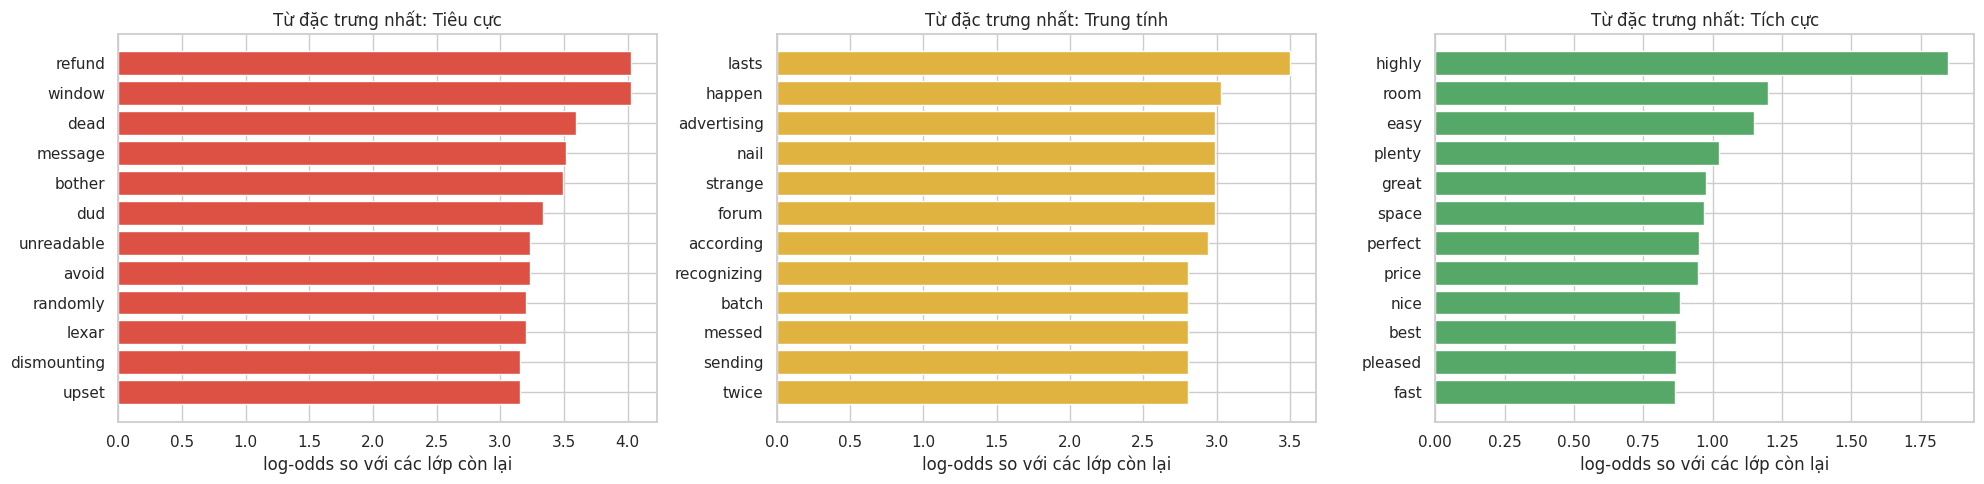

Tiêu cực   : refund, window, dead, message, bother, dud, unreadable, avoid, randomly, lexar, dismounting, upset
Trung tính : lasts, happen, advertising, nail, strange, forum, according, recognizing, batch, messed, sending, twice
Tích cực   : highly, room, easy, plenty, great, space, perfect, price, nice, best, pleased, fast


In [15]:
# Kiểm tra sau làm sạch (chỉ dùng tập TRAIN): độ dài, và các từ đặc trưng nhất của mỗi lớp (log-odds, chỉ để khám phá).
train_text = pd.DataFrame({'raw': X_train['reviewText'], 'clean': cleaner.transform(X_train['reviewText']), 'label': y_train})
print(f"Số từ trung bình: trước = {train_text['raw'].str.split().str.len().mean():.1f} | "
      f"sau = {train_text['clean'].str.split().str.len().mean():.1f}")
print(f"Số đánh giá rỗng sau làm sạch: {(train_text['clean'].str.strip() == '').sum()}")

cv = CountVectorizer(min_df=5, binary=True)
B = cv.fit_transform(train_text['clean'])
vocab = np.array(cv.get_feature_names_out())
doc_freq = {k: np.asarray(B[(train_text['label'] == k).values].sum(axis=0)).ravel() + 1 for k in range(3)}
n_docs = {k: int((train_text['label'] == k).sum()) + 2 for k in range(3)}
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
top_words = {}
for k, ax in zip(range(3), axes):
    rest = sum(doc_freq[j] for j in range(3) if j != k)
    n_rest = sum(n_docs[j] for j in range(3) if j != k)
    logodds = np.log(doc_freq[k] / n_docs[k]) - np.log(rest / n_rest)
    idx = np.argsort(logodds)[::-1][:12]
    top_words[k] = list(vocab[idx])
    ax.barh(vocab[idx][::-1], logodds[idx][::-1], color=CLASS_COLORS[k])
    ax.set(title=f'Từ đặc trưng nhất: {CLASS_NAMES[k]}', xlabel='log-odds so với các lớp còn lại')
plt.tight_layout(); plt.show()
for k in range(3):
    print(f'{CLASS_NAMES[k]:11s}:', ', '.join(top_words[k]))

> **Nhận xét:**
> - Làm sạch giảm độ dài trung bình từ **50.9 xuống 25.0 từ** (khoảng một nửa) và không tạo ra đánh giá rỗng nào. Kiểm tra phủ định cho thấy `doesn't work ... can't recommend` được giữ thành `does not work not recommend`.
> - Từ đặc trưng **Tiêu cực** rất rõ nghĩa: *refund, dead, dud, unreadable, avoid, upset* (hỏng, đòi hoàn tiền). Từ đặc trưng **Tích cực**: *highly, easy, great, perfect, nice, best, pleased, fast*.
> - Danh sách **Trung tính** nhiễu và ít nghĩa (*lasts, nail, strange, forum, batch...*) vì chỉ có khoảng 99 đánh giá Trung tính ở Train; dấu hiệu sớm cho thấy lớp này khó học.

### 2.4. Đặc trưng số bổ sung (meta-features) và Pipeline tiền xử lý
Ngoài TF-IDF, nhóm thử thêm 8 đặc trưng số: 4 cột có sẵn (`day_diff`, `helpful_yes`, `helpful_no`, `total_vote`) và 4 đặc trưng tính từ văn bản
(`word_count`, `char_count`, `exclaim_count` = số dấu `!`, `upper_ratio` = tỉ lệ chữ in hoa). Mục 3 sẽ kiểm tra bằng thực nghiệm xem chúng có giúp ích không.

| Nhánh | Missing | Outlier / Scaling | Encoding |
|---|---|---|---|
| Văn bản (`reviewText`) | `TextCleaner` thay thiếu bằng chuỗi rỗng | — | `TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)` |
| Số, nhóm đếm/tỉ lệ (7 cột: `helpful_yes`, `helpful_no`, `total_vote`, `word_count`, `char_count`, `exclaim_count`, `upper_ratio`) | median (từ Train) | `log1p` để nén đuôi phải, rồi **StandardScaler** | — |
| Số, nhóm thời gian (`day_diff`) | median (từ Train) | chỉ **StandardScaler** (đã gần đối xứng, `log1p` sẽ làm lệch trái) | — |
| Nhãn (`label`) | — | — | Mã hóa thứ bậc 0 < 1 < 2 theo mức độ cảm xúc (Ordinal Encoding) |

Kiểm tra lý do chọn cách scale trước khi dựng pipeline:

,Q1,Median,Q3,P99,IQR,Skew,Skew sau biến đổi,Biến đổi
day_diff,283.000,432.500,605.000,942.630,322.000,0.126,0.126,chỉ scale
helpful_yes,0.000,0.000,0.000,3.000,0.000,34.626,10.087,log1p + scale
helpful_no,0.000,0.000,0.000,2.000,0.000,30.130,10.057,log1p + scale
total_vote,0.000,0.000,0.000,4.000,0.000,34.076,8.068,log1p + scale
word_count,23.000,33.000,55.000,264.520,32.000,9.139,0.661,log1p + scale
char_count,123.000,173.000,289.000,"1,427.980",166.000,9.363,0.547,log1p + scale
exclaim_count,0.000,0.000,0.000,3.630,0.000,8.332,2.671,log1p + scale
upper_ratio,0.023,0.034,0.048,0.147,0.026,11.578,9.242,log1p + scale


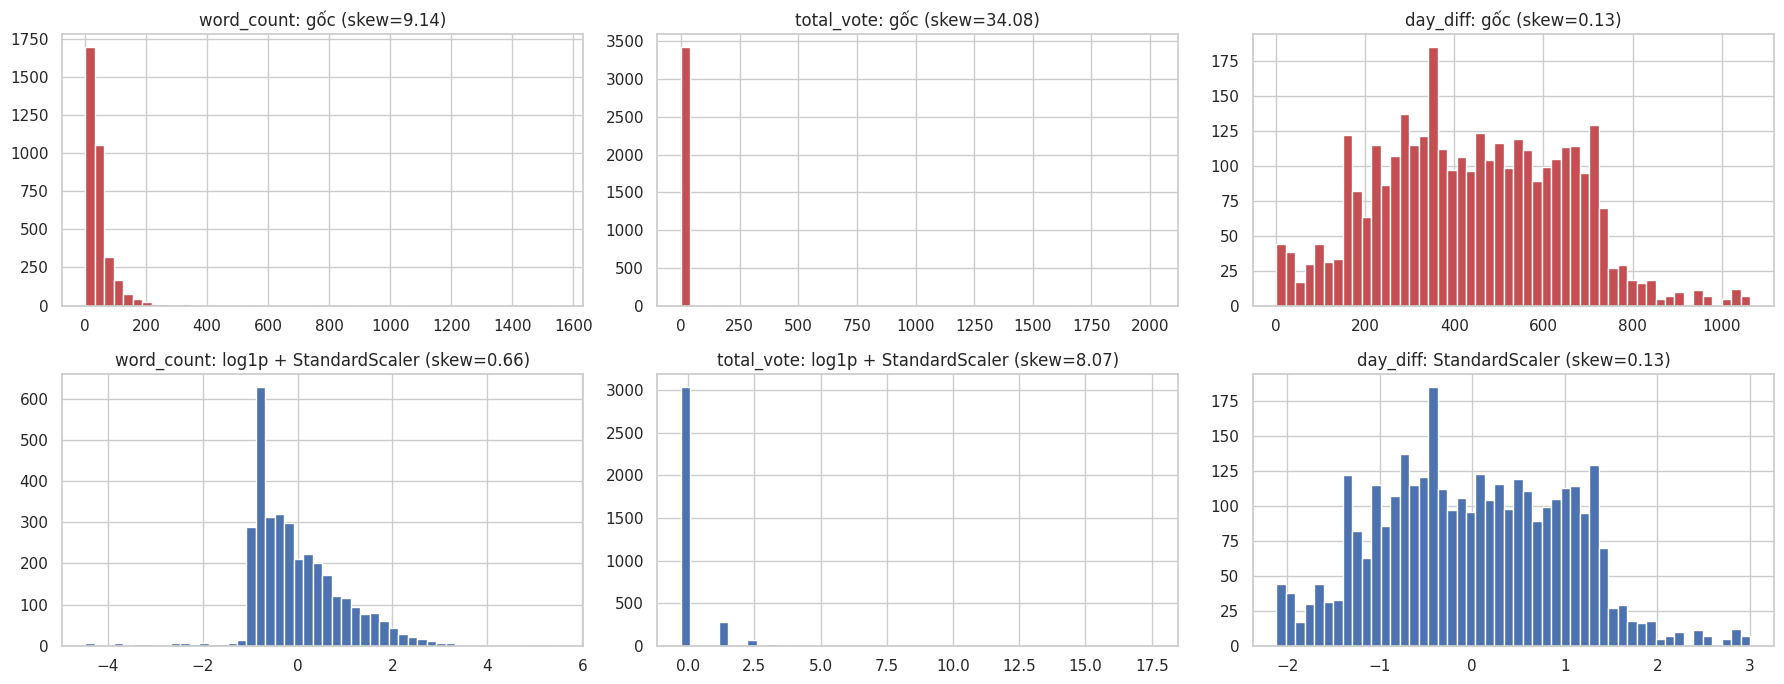

In [16]:
def add_meta_features(X):
    X = X.copy()
    text = X['reviewText'].fillna('')
    X['word_count'] = text.str.split().str.len()
    X['char_count'] = text.str.len()
    X['exclaim_count'] = text.str.count('!')
    X['upper_ratio'] = text.apply(lambda t: sum(c.isupper() for c in t) / max(len(t), 1))
    return X


LOG_COLS = ['helpful_yes', 'helpful_no', 'total_vote', 'word_count', 'char_count', 'exclaim_count', 'upper_ratio']
PLAIN_COLS = ['day_diff']
NUM_COLS = PLAIN_COLS + LOG_COLS
meta_train = add_meta_features(X_train)[NUM_COLS]

q = meta_train.quantile([.25, .5, .75, .99]).T
q['IQR'] = q[0.75] - q[0.25]
q['Skew'] = meta_train.skew()
q['Skew sau biến đổi'] = [np.log1p(meta_train[c]).skew() if c in LOG_COLS else meta_train[c].skew() for c in q.index]
q['Biến đổi'] = ['log1p + scale' if c in LOG_COLS else 'chỉ scale' for c in q.index]
display(q.rename(columns={0.25: 'Q1', 0.5: 'Median', 0.75: 'Q3', 0.99: 'P99'}))

fig, axes = plt.subplots(2, 3, figsize=(18, 7))
for j, c in enumerate(['word_count', 'total_vote', 'day_diff']):
    v = meta_train[c]
    axes[0, j].hist(v, bins=50, color='#C44E52'); axes[0, j].set_title(f'{c}: gốc (skew={v.skew():.2f})')
    base = np.log1p(v.to_frame()) if c in LOG_COLS else v.to_frame()
    s = StandardScaler().fit_transform(base)
    how = 'log1p + StandardScaler' if c in LOG_COLS else 'StandardScaler'
    axes[1, j].hist(s, bins=50, color='#4C72B0'); axes[1, j].set_title(f'{c}: {how} (skew={pd.Series(s.ravel()).skew():.2f})')
plt.tight_layout(); plt.show()

> **Nhận xét:** Việc chọn cách scale dựa trên số liệu ở Train:
> - `day_diff` đã gần đối xứng (skew = 0.13) → **chỉ StandardScaler**, `log1p` sẽ làm lệch.
> - `word_count` (skew 9.14 → **0.66**) và `char_count` (9.36 → **0.55**) được `log1p` kéo về gần đối xứng; `exclaim_count` giảm từ 8.33 xuống 2.67.
> - Các cột bình chọn giảm mạnh (`helpful_yes` 34.6 → 10.1, `helpful_no` 30.1 → 10.1, `total_vote` 34.1 → 8.1) nhưng **vẫn lệch** vì đa số bằng 0 (cột có một "cột nhọn" tại 0, `log1p` không thể xử lý). `upper_ratio` cũng còn lệch (11.6 → 9.2).

In [17]:
def build_preprocessor(use_meta=False):
    # Nhánh văn bản: làm sạch -> TF-IDF. Nhánh số (tùy chọn): điền thiếu -> (log1p) -> StandardScaler.
    text_branch = Pipeline([
        ('clean', TextCleaner()),
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
    ])
    transformers = [('text', text_branch, 'reviewText')]
    if use_meta:
        log_branch = Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('log1p', FunctionTransformer(np.log1p)),
            ('scale', StandardScaler()),
        ])
        plain_branch = Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
        ])
        transformers += [('num_log', log_branch, LOG_COLS), ('num_plain', plain_branch, PLAIN_COLS)]
    return ColumnTransformer(transformers)


def make_pipeline(clf, use_meta=False):
    steps = []
    if use_meta:
        steps.append(('meta', FunctionTransformer(add_meta_features)))   # tạo meta-features từ dữ liệu thô
    steps += [('prep', build_preprocessor(use_meta)), ('clf', clf)]
    return Pipeline(steps)


demo_pipe = make_pipeline(LogisticRegression(max_iter=2000), use_meta=True).fit(X_train, y_train)
Z = demo_pipe[:-1].transform(X_train)
print(f'Ma trận đặc trưng Train: {Z.shape[0]:,} mẫu × {Z.shape[1]:,} đặc trưng '
      f'(5,000 TF-IDF + {len(NUM_COLS)} số) | độ thưa: {1 - Z.nnz / (Z.shape[0] * Z.shape[1]):.1%}')

Ma trận đặc trưng Train: 3,438 mẫu × 5,008 đặc trưng (5,000 TF-IDF + 8 số) | độ thưa: 99.3%


> **Nhận xét:** Ma trận đặc trưng Train có **3,438 mẫu × 5,008 đặc trưng** (5,000 TF-IDF + 8 số), độ thưa **99.3%** → dùng ma trận thưa và các mô hình tuyến tính/Naive Bayes là hợp lý. Số đặc trưng (5,008) lớn hơn số mẫu (3,438) nên cần điều chuẩn (tham số `C`/`alpha`) và đã được tinh chỉnh ở 3.3.

## 3. PHÂN TÍCH VÀ MÔ HÌNH HÓA

### 3.1. Thước đo đánh giá
Với 3 lớp và ~90% là lớp Tích cực, Accuracy rất dễ gây hiểu nhầm. Nhóm báo cáo đủ 5 thước đo theo yêu cầu đề bài, tính **trung bình macro**
(mỗi lớp có trọng số bằng nhau, nên lớp hiếm không bị lớp đông "nuốt"):
- **F1 macro** — thước đo chính để chọn mô hình (cân bằng Precision và Recall, công bằng giữa 3 lớp).
- **Precision macro, Recall macro, Accuracy.**
- **ROC-AUC macro (one-vs-rest)** — khả năng xếp hạng, không phụ thuộc ngưỡng; tính từ xác suất hoặc `decision_function` (với LinearSVC).
- **F1 lớp Trung tính** — theo dõi riêng vì đây là lớp khó nhất và hiếm nhất.

### 3.2. Baseline và so sánh các mô hình (trên Validation)
- **Baseline 1 — Dummy:** luôn đoán lớp đa số.
- **Baseline 2 — Logistic Regression** tham số mặc định, không xử lý mất cân bằng.
- **3 thuật toán theo đề:** MultinomialNB, Logistic Regression, LinearSVC — mỗi thuật toán chạy **hai phiên bản**: mặc định và phiên bản xử lý mất cân bằng
  (`class_weight='balanced'` cho LogReg/LinearSVC; `fit_prior=False` cho MultinomialNB, tức là dùng xác suất tiên nghiệm đều thay vì theo tần suất lớp).

In [18]:
CLASSES = [0, 1, 2]


def get_scores(model, X):
    # Điểm số theo lớp: xác suất nếu có, ngược lại dùng decision_function (LinearSVC).
    return model.predict_proba(X) if hasattr(model, 'predict_proba') else model.decision_function(X)


def macro_auc(y_true, scores):
    Y = label_binarize(y_true, classes=CLASSES)
    return float(np.mean([roc_auc_score(Y[:, k], scores[:, k]) for k in CLASSES]))


def evaluate(model, X, y_true):
    pred = model.predict(X)
    return {'Accuracy': accuracy_score(y_true, pred),
            'Precision': precision_score(y_true, pred, average='macro', zero_division=0),
            'Recall': recall_score(y_true, pred, average='macro', zero_division=0),
            'F1': f1_score(y_true, pred, average='macro', zero_division=0),
            'ROC-AUC': macro_auc(y_true, get_scores(model, X)),
            'F1 Trung tính': f1_score(y_true, pred, labels=[1], average='macro', zero_division=0)}


METRIC_FMT = {c: '{:.3f}' for c in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'F1 Trung tính']}

ALGORITHMS = {
    'MultinomialNB': {'default': lambda: MultinomialNB(), 'balanced': lambda: MultinomialNB(fit_prior=False)},
    'LogisticRegression': {'default': lambda: LogisticRegression(max_iter=2000),
                           'balanced': lambda: LogisticRegression(max_iter=2000, class_weight='balanced')},
    'LinearSVC': {'default': lambda: LinearSVC(random_state=RANDOM_STATE),
                  'balanced': lambda: LinearSVC(class_weight='balanced', random_state=RANDOM_STATE)},
}

models = {'Dummy (lớp đa số)': make_pipeline(DummyClassifier(strategy='most_frequent'))}
for name, versions in ALGORITHMS.items():
    models[name] = make_pipeline(versions['default']())
    models[f'{name} + balanced'] = make_pipeline(versions['balanced']())

val_rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    val_rows.append({'Mô hình': name, **evaluate(model, X_val, y_val)})
val_results = pd.DataFrame(val_rows).set_index('Mô hình')
display(val_results.style.format(METRIC_FMT).highlight_max(color='#c6efce', axis=0))

,Accuracy,Precision,Recall,F1,ROC-AUC,F1 Trung tính
Mô hình,,,,,,
Dummy (lớp đa số),0.905,0.302,0.333,0.317,0.500,0.000
MultinomialNB,0.905,0.302,0.333,0.317,0.830,0.000
MultinomialNB + balanced,0.919,0.517,0.452,0.473,0.824,0.000
LogisticRegression,0.925,0.603,0.435,0.472,0.898,0.000
LogisticRegression + balanced,0.910,0.574,0.636,0.599,0.877,0.195
LinearSVC,0.932,0.569,0.488,0.516,0.876,0.000
LinearSVC + balanced,0.932,0.622,0.535,0.560,0.875,0.077


**Câu hỏi: xử lý mất cân bằng thay đổi F1 macro và F1 lớp Trung tính của từng thuật toán thế nào?**

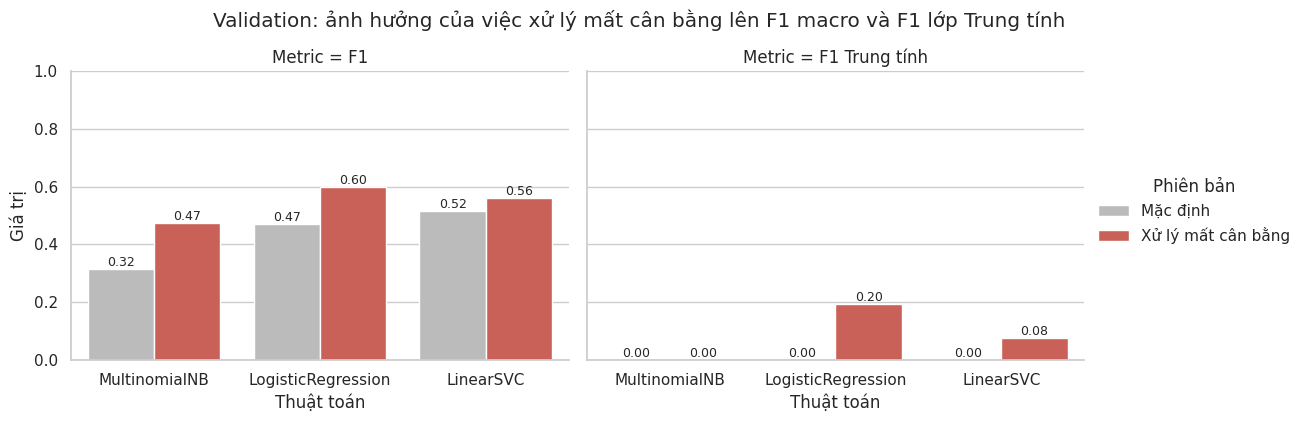

In [19]:
plot_rows = []
for name in ALGORITHMS:
    for suffix, label in [('', 'Mặc định'), (' + balanced', 'Xử lý mất cân bằng')]:
        r = val_results.loc[name + suffix]
        plot_rows += [{'Thuật toán': name, 'Phiên bản': label, 'Metric': m, 'Giá trị': r[m]} for m in ['F1', 'F1 Trung tính']]
plot_df = pd.DataFrame(plot_rows)

g = sns.catplot(data=plot_df, x='Thuật toán', y='Giá trị', hue='Phiên bản', col='Metric', kind='bar',
                palette=['#BBBBBB', '#DD5145'], height=4, aspect=1.4)
for ax in g.axes.flat:
    for c in ax.containers:
        ax.bar_label(c, fmt='%.2f', fontsize=9)
    ax.set_ylim(0, 1)
g.figure.suptitle('Validation: ảnh hưởng của việc xử lý mất cân bằng lên F1 macro và F1 lớp Trung tính', y=1.05)
plt.show()

> **Nhận xét (Validation, 737 mẫu):**
> - **Dummy** đạt Accuracy 0.905 nhưng F1 macro chỉ 0.317. **LogReg mặc định** có F1 0.472 và F1 Trung tính = **0.000** (không bắt được đánh giá Trung tính nào).
> - **Xử lý mất cân bằng tăng F1 macro ở cả 3 thuật toán:** MultinomialNB 0.317 → **0.473**, LogReg 0.472 → **0.599**, LinearSVC 0.516 → **0.560**.
> - **F1 lớp Trung tính chỉ nhích lên ở LogReg (0 → 0.195) và LinearSVC (0 → 0.077)**; MultinomialNB vẫn bằng 0.
> - Cái giá phải trả: Recall tăng (LogReg 0.435 → 0.636) nhưng Accuracy giảm (0.925 → 0.910) vì mô hình báo nhầm nhiều đánh giá Tích cực thành Tiêu cực/Trung tính. LinearSVC giữ Accuracy 0.932.

### 3.3. Tinh chỉnh siêu tham số (GridSearchCV, 5-fold phân tầng trên Train)
Tinh chỉnh cả 3 thuật toán; cấu hình TF-IDF được giữ cố định đúng như đề (`max_features=5000`, `ngram_range=(1, 2)`).
Việc xử lý mất cân bằng (`class_weight` / `fit_prior`) được coi là một siêu tham số; tiêu chí chọn là **F1 macro**.
Quá trình tìm kiếm chỉ dùng Train (cross-validation); Validation chỉ dùng để so sánh các mô hình đã tuning.

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
GRIDS = {
    'MultinomialNB': (MultinomialNB(), {'clf__alpha': [0.05, 0.1, 0.3, 1.0], 'clf__fit_prior': [True, False]}),
    'LogisticRegression': (LogisticRegression(max_iter=2000),
                           {'clf__C': [0.3, 1, 3, 10, 30], 'clf__class_weight': [None, 'balanced']}),
    'LinearSVC': (LinearSVC(random_state=RANDOM_STATE),
                  {'clf__C': [0.03, 0.1, 0.3, 1, 3], 'clf__class_weight': [None, 'balanced']}),
}

tuned, tune_rows = {}, []
for name, (clf, grid) in GRIDS.items():
    search = GridSearchCV(make_pipeline(clf), grid, scoring='f1_macro', cv=cv, n_jobs=-1).fit(X_train, y_train)
    tuned[name] = search.best_estimator_
    tune_rows.append({'Mô hình': f'{name} (tuned)', 'CV F1': search.best_score_, **evaluate(tuned[name], X_val, y_val),
                      'Tham số tốt nhất': {k.replace('clf__', ''): v for k, v in search.best_params_.items()}})
tune_results = pd.DataFrame(tune_rows).set_index('Mô hình')
display(tune_results.drop(columns='Tham số tốt nhất').style.format({**METRIC_FMT, 'CV F1': '{:.3f}'}).highlight_max(color='#c6efce', axis=0))
for name, params in tune_results['Tham số tốt nhất'].items():
    print(f'{name}: {params}')

,CV F1,Accuracy,Precision,Recall,F1,ROC-AUC,F1 Trung tính
Mô hình,,,,,,,
MultinomialNB (tuned),0.554,0.858,0.490,0.620,0.527,0.862,0.111
LogisticRegression (tuned),0.585,0.925,0.625,0.629,0.620,0.878,0.235
LinearSVC (tuned),0.562,0.932,0.622,0.535,0.560,0.875,0.077


MultinomialNB (tuned): {'alpha': 0.05, 'fit_prior': False}
LogisticRegression (tuned): {'C': 3, 'class_weight': 'balanced'}
LinearSVC (tuned): {'C': 1, 'class_weight': 'balanced'}


> **Nhận xét:**
> - Tham số tốt nhất: MultinomialNB `alpha=0.05, fit_prior=False`; LogReg `C=3, class_weight='balanced'`; LinearSVC `C=1, class_weight='balanced'`. **Cả ba đều chọn xử lý mất cân bằng** khi coi nó là siêu tham số.
> - CV F1 (Train): LogReg **0.585** > LinearSVC 0.562 > MultinomialNB 0.554. Trên Validation, F1 macro: LogReg **0.620** > LinearSVC 0.560 > MultinomialNB 0.527.
> - Tuning giúp LogReg rõ nhất (0.599 → 0.620, F1 Trung tính 0.195 → 0.235). LinearSVC không đổi vì `C=1` + `balanced` trùng với phiên bản mặc định đã chạy. MultinomialNB có Recall cao (0.620) nhưng Accuracy chỉ 0.858 do báo nhầm nhiều.
> - Chênh lệch giữa CV (0.585) và Validation (0.620) cho thấy ước lượng F1 dao động đáng kể vì lớp thiểu số quá ít mẫu.

### 3.4. Thử nghiệm: thêm đặc trưng số (meta-features) có giúp ích không?
Với hai mô hình tuyến tính tốt nhất (MultinomialNB không dùng được vì `StandardScaler` tạo giá trị âm), nhóm giữ nguyên siêu tham số đã tuning
và so sánh **chỉ-TF-IDF** với **TF-IDF + 8 đặc trưng số** (đã điền thiếu, `log1p` cho nhóm đếm/tỉ lệ, `StandardScaler`) trên cùng tập Validation.

In [21]:
meta_rows, tuned_meta = [], {}
for name in ['LogisticRegression', 'LinearSVC']:
    best_clf = clone(tuned[name].named_steps['clf'])
    tuned_meta[name] = make_pipeline(best_clf, use_meta=True).fit(X_train, y_train)
    for label, model in [('chỉ TF-IDF', tuned[name]), ('TF-IDF + meta-features', tuned_meta[name])]:
        meta_rows.append({'Mô hình': f'{name} ({label})', **evaluate(model, X_val, y_val)})
meta_results = pd.DataFrame(meta_rows).set_index('Mô hình')
display(meta_results.style.format(METRIC_FMT).highlight_max(color='#c6efce', axis=0))

,Accuracy,Precision,Recall,F1,ROC-AUC,F1 Trung tính
Mô hình,,,,,,
LogisticRegression (chỉ TF-IDF),0.925,0.625,0.629,0.620,0.878,0.235
LogisticRegression (TF-IDF + meta-features),0.920,0.609,0.636,0.619,0.894,0.263
LinearSVC (chỉ TF-IDF),0.932,0.622,0.535,0.560,0.875,0.077
LinearSVC (TF-IDF + meta-features),0.934,0.555,0.533,0.543,0.891,0.000


> **Nhận xét:** Thêm meta-features **không cải thiện F1 macro**: LogReg 0.620 → 0.619 (gần như bằng nhau), LinearSVC 0.560 → 0.543 (giảm). ROC-AUC tăng ở cả hai (LogReg 0.878 → 0.894, LinearSVC 0.875 → 0.891), nhưng F1 Trung tính của LinearSVC tụt về 0.000.
> Phù hợp với mục 1.7: các đặc trưng số chỉ tương quan yếu với nhãn, thông tin đã nằm sẵn trong TF-IDF (độ dài ~ số từ). Nhóm vẫn đưa cả hai cấu hình vào bước chọn cuối để quyết định bằng số liệu.

### 3.5. Chọn mô hình cuối (dựa trên Validation, không dùng Test)
Mô hình cuối là mô hình có **F1 macro cao nhất trên Validation** trong số các cấu hình đã tuning (có hoặc không có meta-features).

In [22]:
candidates = {f'{n} (tuned)': m for n, m in tuned.items()}
candidates.update({f'{n} (tuned + meta)': m for n, m in tuned_meta.items()})
cand_val = pd.DataFrame({k: evaluate(m, X_val, y_val) for k, m in candidates.items()}).T.sort_values('F1', ascending=False)
display(cand_val.style.format(METRIC_FMT).highlight_max(color='#c6efce', axis=0))

best_name = cand_val.index[0]
final_model = candidates[best_name]
print(f'Mô hình cuối (chọn theo F1 macro trên Validation): {best_name}')
print('Siêu tham số:', {k: v for k, v in final_model.named_steps['clf'].get_params().items() if k in ('C', 'alpha', 'class_weight', 'fit_prior')})

,Accuracy,Precision,Recall,F1,ROC-AUC,F1 Trung tính
LogisticRegression (tuned),0.925,0.625,0.629,0.620,0.878,0.235
LogisticRegression (tuned + meta),0.920,0.609,0.636,0.619,0.894,0.263
LinearSVC (tuned),0.932,0.622,0.535,0.560,0.875,0.077
LinearSVC (tuned + meta),0.934,0.555,0.533,0.543,0.891,0.000
MultinomialNB (tuned),0.858,0.490,0.620,0.527,0.862,0.111


Mô hình cuối (chọn theo F1 macro trên Validation): LogisticRegression (tuned)
Siêu tham số: {'C': 3, 'class_weight': 'balanced'}


> **Nhận xét:** **LogisticRegression (tuned)** (`C=3`, `class_weight='balanced'`, chỉ TF-IDF) có F1 macro cao nhất trên Validation (**0.620**).
> Lưu ý: bản có meta-features (**0.619**) chỉ kém 0.001, thực chất là hòa, nên ưu tiên mô hình **đơn giản hơn** (không cần thêm 8 đặc trưng). Validation chỉ có 21 đánh giá Trung tính nên thứ hạng giữa các mô hình sát nhau không đáng tin tuyệt đối; điều này được kiểm tra lại trên Test ở Phần 4.

## 4. TỔNG KẾT VÀ MỞ RỘNG

### 4.1. Đánh giá trên tập Test độc lập
Mô hình, siêu tham số và cấu hình đặc trưng đều đã được chốt ở Phần 3 (dựa trên Validation); tập Test chỉ được dùng **một lần** ở đây.
Bảng dưới so sánh tất cả mô hình trên cùng tập Test với 5 thước đo của đề (Accuracy, Precision, Recall, F1, ROC-AUC; trung bình macro).

,Accuracy,Precision,Recall,F1,ROC-AUC,F1 Trung tính
Dummy (lớp đa số),0.905,0.302,0.333,0.317,0.500,0.000
LogisticRegression (baseline),0.923,0.597,0.424,0.458,0.907,0.000
MultinomialNB (tuned),0.847,0.483,0.614,0.518,0.850,0.091
LogisticRegression (tuned),0.919,0.575,0.621,0.593,0.884,0.154
LinearSVC (tuned),0.929,0.671,0.573,0.597,0.877,0.207
LogisticRegression (tuned + meta),0.919,0.554,0.600,0.572,0.880,0.103
LinearSVC (tuned + meta),0.927,0.595,0.570,0.578,0.873,0.121


=== LogisticRegression (tuned) — TẬP TEST (737 mẫu) ===
              precision    recall  f1-score   support

    Tiêu cực      0.578     0.771     0.661        48
  Trung tính      0.176     0.136     0.154        22
    Tích cực      0.971     0.955     0.963       667

    accuracy                          0.919       737
   macro avg      0.575     0.621     0.593       737
weighted avg      0.922     0.919     0.919       737



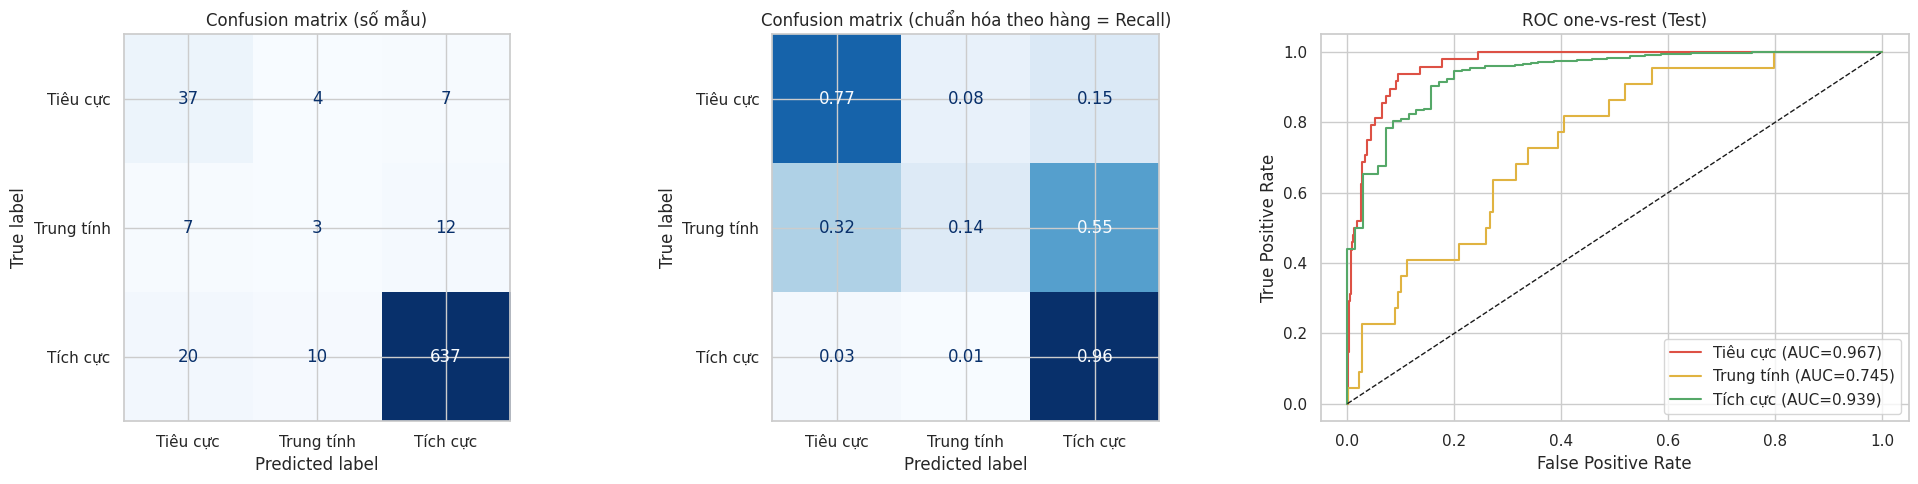

ROC-AUC theo lớp (Test): {'Tiêu cực': 0.967, 'Trung tính': 0.745, 'Tích cực': 0.939}


In [23]:
test_models = {'Dummy (lớp đa số)': models['Dummy (lớp đa số)'], 'LogisticRegression (baseline)': models['LogisticRegression'], **candidates}
test_results = pd.DataFrame({k: evaluate(m, X_test, y_test) for k, m in test_models.items()}).T
display(test_results.style.format(METRIC_FMT).highlight_max(color='#c6efce', axis=0))

test_pred = final_model.predict(X_test)
test_scores = get_scores(final_model, X_test)
print(f'=== {best_name} — TẬP TEST ({len(y_test)} mẫu) ===')
print(classification_report(y_test, test_pred, target_names=[CLASS_NAMES[k] for k in CLASSES], digits=3, zero_division=0))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
labels = [CLASS_NAMES[k] for k in CLASSES]
ConfusionMatrixDisplay(confusion_matrix(y_test, test_pred), display_labels=labels).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion matrix (số mẫu)')
ConfusionMatrixDisplay(confusion_matrix(y_test, test_pred, normalize='true'), display_labels=labels).plot(
    ax=axes[1], cmap='Blues', colorbar=False, values_format='.2f')
axes[1].set_title('Confusion matrix (chuẩn hóa theo hàng = Recall)')
Y_test = label_binarize(y_test, classes=CLASSES)
for k in CLASSES:
    fpr, tpr, _ = roc_curve(Y_test[:, k], test_scores[:, k])
    axes[2].plot(fpr, tpr, color=CLASS_COLORS[k], label=f'{CLASS_NAMES[k]} (AUC={roc_auc_score(Y_test[:, k], test_scores[:, k]):.3f})')
axes[2].plot([0, 1], [0, 1], 'k--', lw=1)
axes[2].set(title='ROC one-vs-rest (Test)', xlabel='False Positive Rate', ylabel='True Positive Rate'); axes[2].legend()
plt.tight_layout(); plt.show()
print('ROC-AUC theo lớp (Test):', {CLASS_NAMES[k]: round(float(roc_auc_score(Y_test[:, k], test_scores[:, k])), 3) for k in CLASSES})

> **Nhận xét (Test, 737 mẫu, dùng một lần):**
> - Mô hình cuối: Accuracy **0.919**, F1 macro **0.593**, ROC-AUC macro **0.884**; cao hơn hẳn Dummy (F1 0.317) và LogReg baseline (F1 0.458).
> - Theo lớp: **Tiêu cực** F1 0.661 (Precision 0.578, Recall **0.771**); **Tích cực** F1 0.963; **Trung tính** F1 chỉ **0.154** (Precision 0.176, Recall 0.136).
> - ROC-AUC theo lớp: Tiêu cực **0.967**, Tích cực 0.939, Trung tính **0.745** → mô hình *xếp hạng* tốt đánh giá tiêu cực, nhưng gần như không tách được lớp Trung tính.
> - F1 trên Test (0.593) thấp hơn Validation (0.620), bình thường khi chỉ có 48 mẫu Tiêu cực và 22 mẫu Trung tính. LinearSVC (tuned) đạt 0.597 trên Test, hơn 0.004 và nằm trong sai số; nhóm **không đổi mô hình theo Test** vì mô hình đã được chốt trên Validation (đổi theo Test sẽ làm rò rỉ).
> - Accuracy (0.919) thấp hơn baseline (0.923): cái giá của việc ưu tiên bắt lớp thiểu số.

### 4.2. Câu hỏi: *Xử lý mất cân bằng và tuning giúp bắt thêm được bao nhiêu đánh giá tiêu cực / trung tính trên tập Test?*
So sánh 3 cấu hình trên **cùng tập Test**:
1. **Baseline** — Logistic Regression mặc định, không xử lý mất cân bằng.
2. **+ xử lý mất cân bằng** — Logistic Regression với `class_weight='balanced'`, cùng tham số mặc định.
3. **Mô hình cuối** — cấu hình đã tuning bằng GridSearchCV và chọn trên Validation.

,Accuracy,F1,ROC-AUC,Bắt Tiêu cực,Bắt Trung tính,Báo nhầm → Tiêu cực,Báo nhầm → Trung tính
Cấu hình,,,,,,,
1. Baseline LogReg,0.923,0.458,0.907,13,0,2,0
2. + class_weight (LogReg),0.904,0.577,0.878,40,3,37,19
3. Mô hình cuối: LogisticRegression (tuned),0.919,0.593,0.884,37,3,27,14


Tập Test có 48 đánh giá Tiêu cực và 22 đánh giá Trung tính.


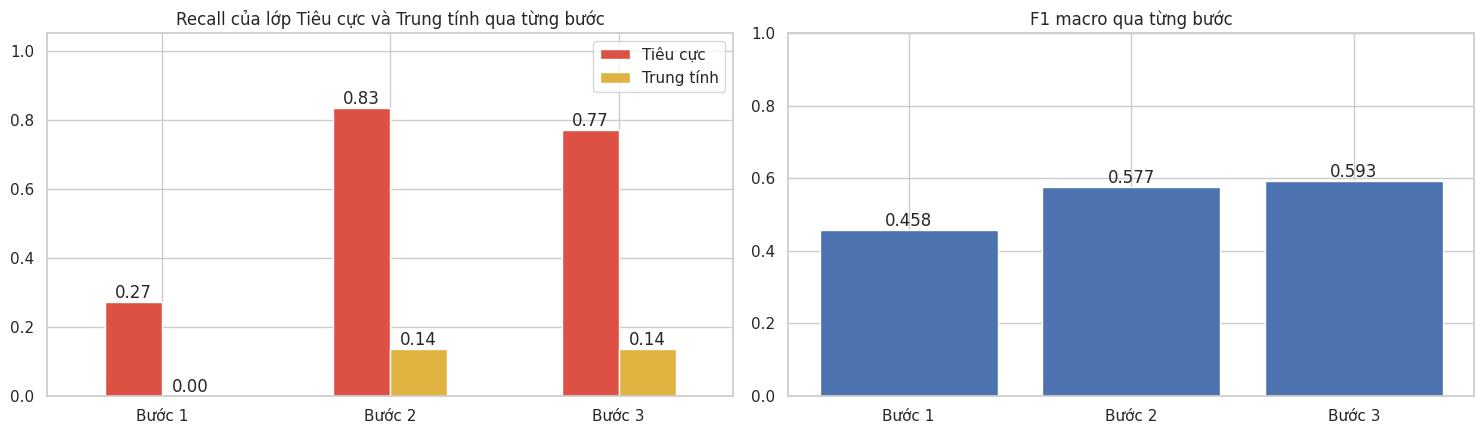

In [24]:
n_neg, n_neu = int((y_test == 0).sum()), int((y_test == 1).sum())
steps = [('1. Baseline LogReg', models['LogisticRegression']),
         ('2. + class_weight (LogReg)', models['LogisticRegression + balanced']),
         (f'3. Mô hình cuối: {best_name}', final_model)]
step_rows = []
for label, model in steps:
    pred = model.predict(X_test)
    cm = confusion_matrix(y_test, pred, labels=CLASSES)
    step_rows.append({'Cấu hình': label, **{k: v for k, v in evaluate(model, X_test, y_test).items() if k in ('Accuracy', 'F1', 'ROC-AUC')},
                      'Bắt Tiêu cực': int(cm[0, 0]), 'Bắt Trung tính': int(cm[1, 1]),
                      'Báo nhầm → Tiêu cực': int(cm[1:, 0].sum()), 'Báo nhầm → Trung tính': int(cm[[0, 2], 1].sum())})
steps_df = pd.DataFrame(step_rows).set_index('Cấu hình')
display(steps_df.style.format({'Accuracy': '{:.3f}', 'F1': '{:.3f}', 'ROC-AUC': '{:.3f}'}))
print(f'Tập Test có {n_neg} đánh giá Tiêu cực và {n_neu} đánh giá Trung tính.')

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
rec = pd.DataFrame({'Tiêu cực': steps_df['Bắt Tiêu cực'] / n_neg, 'Trung tính': steps_df['Bắt Trung tính'] / n_neu})
rec.index = [f'Bước {i + 1}' for i in range(len(rec))]
rec.plot.bar(ax=axes[0], rot=0, color=[CLASS_COLORS[0], CLASS_COLORS[1]], ylim=(0, 1.05))
for c in axes[0].containers:
    axes[0].bar_label(c, fmt='%.2f')
axes[0].set(title='Recall của lớp Tiêu cực và Trung tính qua từng bước')
axes[1].bar(rec.index, steps_df['F1'].values, color='#4C72B0')
for x, v in enumerate(steps_df['F1'].values):
    axes[1].text(x, v + .01, f'{v:.3f}', ha='center')
axes[1].set(title='F1 macro qua từng bước', ylim=(0, 1))
plt.tight_layout(); plt.show()

> **Nhận xét (Test: 48 Tiêu cực, 22 Trung tính):**
> - **Bước 1 → 2 (class_weight):** số đánh giá Tiêu cực bắt được tăng **13 → 40** (Recall 0.27 → 0.83), F1 macro 0.458 → **0.577**. Đánh đổi: báo nhầm vào lớp Tiêu cực tăng **2 → 37** và vào lớp Trung tính **0 → 19**.
> - **Bước 2 → 3 (tuning):** bắt **37** Tiêu cực nhưng giảm báo nhầm (37 → **27**; Trung tính 19 → **14**), F1 macro **0.593**. Precision tiêu cực cải thiện (40/77 → 37/64 = 0.578).
> - **Lớp Trung tính:** chỉ bắt được **3/22 (13.6%)** dù đã xử lý mất cân bằng và tuning; baseline bắt **0**. Xử lý mất cân bằng giúp đáng kể với lớp Tiêu cực, nhưng **không đủ** với lớp Trung tính.
> - Tổng: cứ mỗi đánh giá Tiêu cực bắt thêm (13 → 37, +24) thì có thêm khoảng 25 cảnh báo sai (2 → 27); với bộ phận chăm sóc khách hàng, đây là đánh đổi có thể chấp nhận vì bỏ sót khiếu nại tốn kém hơn.

### 4.3. Đặc trưng quan trọng: những từ nào kéo mô hình về từng lớp?
Với mô hình tuyến tính, hệ số của từng từ TF-IDF cho biết từ đó đẩy dự đoán về lớp nào (với MultinomialNB dùng chênh lệch log-xác suất so với trung bình các lớp).

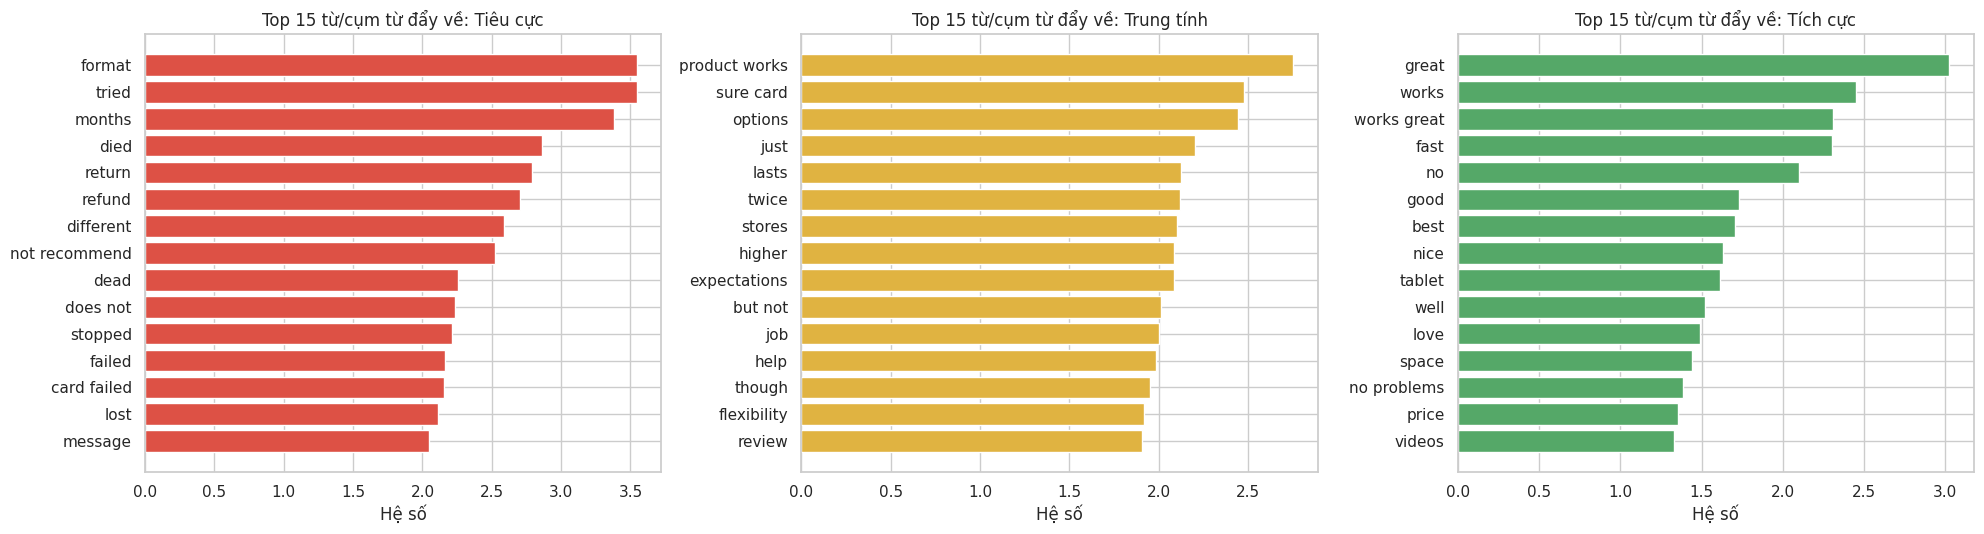

Tiêu cực   : format, tried, months, died, return, refund, different, not recommend, dead, does not, stopped, failed, card failed, lost, message
Trung tính : product works, sure card, options, just, lasts, twice, stores, higher, expectations, but not, job, help, though, flexibility, review
Tích cực   : great, works, works great, fast, no, good, best, nice, tablet, well, love, space, no problems, price, videos


In [25]:
def class_word_weights(model):
    tfidf = model.named_steps['prep'].named_transformers_['text'].named_steps['tfidf']
    names = np.array(tfidf.get_feature_names_out())
    clf = model.named_steps['clf']
    if hasattr(clf, 'coef_'):
        W = clf.coef_[:, :len(names)]
    else:
        W = clf.feature_log_prob_ - clf.feature_log_prob_.mean(axis=0)
    return names, W


names, W = class_word_weights(final_model)
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
top_by_class = {}
for k, ax in zip(CLASSES, axes):
    idx = np.argsort(W[k])[::-1][:15]
    top_by_class[k] = list(names[idx])
    ax.barh(names[idx][::-1], W[k][idx][::-1], color=CLASS_COLORS[k])
    ax.set(title=f'Top 15 từ/cụm từ đẩy về: {CLASS_NAMES[k]}', xlabel='Hệ số')
plt.tight_layout(); plt.show()
for k in CLASSES:
    print(f'{CLASS_NAMES[k]:11s}:', ', '.join(top_by_class[k]))

> **Nhận xét:**
> - **Tiêu cực:** các từ về hỏng hóc/đòi quyền lợi: *died, dead, failed, stopped, refund, return, lost, message*, cụm *not recommend*, *does not*, *card failed*. Nhờ giữ từ phủ định ở bước làm sạch, các cụm này mới xuất hiện được.
> - **Tích cực:** *great, works, works great, fast, good, best, love, price, space*, và cụm *no problems* (từ `no` được giữ lại nhờ `KEEP_WORDS`).
> - **Trung tính:** từ yếu và phân tán (*but not, though, job, expectations, twice, stores, flexibility*): vài từ mang tính "tạm được/có điều kiện" nhưng nhiều từ có vẻ ngẫu nhiên, vì lớp này chỉ có khoảng 99 mẫu Train. Điều này lý giải vì sao Trung tính là lớp khó nhất.

### 4.4. Phân tích lỗi (Error Analysis)
Mô hình hay đoán nhầm lớp nào sang lớp nào, và vì sao? Nhóm dùng lại điểm sao gốc (1–5) để xem lỗi tập trung ở mức sao nào.

Phân bố dự đoán theo điểm sao gốc (số mẫu):


pred,Tiêu cực,Trung tính,Tích cực
stars,,,
1,27,2,6
2,10,2,1
3,7,3,12
4,6,2,73
5,14,8,564


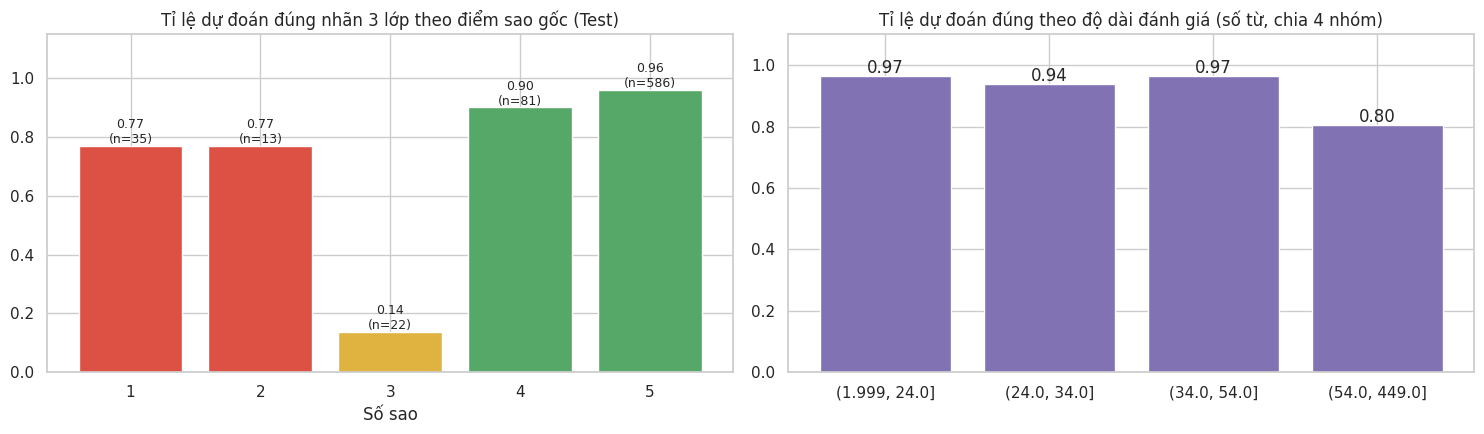

,Tỉ lệ đúng,Số mẫu
stars,,
1,0.771,35
2,0.769,13
3,0.136,22
4,0.901,81
5,0.962,586


,Tỉ lệ đúng,Số mẫu
len_bin,,
"(1.999, 24.0]",0.965,202
"(24.0, 34.0]",0.939,179
"(34.0, 54.0]",0.965,172
"(54.0, 449.0]",0.804,184


Các kiểu nhầm lẫn (thực tế → dự đoán):
  Tích cực   → Tiêu cực  : 20
  Trung tính → Tích cực  : 12
  Tích cực   → Trung tính: 10
  Tiêu cực   → Tích cực  : 7
  Trung tính → Tiêu cực  : 7
  Tiêu cực   → Trung tính: 4

--- Thực tế Tiêu cực → dự đoán Tích cực (các ca mô hình "tự tin" nhất) ---
[1 sao] forget loading this into your cart.  a one day pause and this junk went up 16.99, in ONE DAY.  I don't give money to aXXholes.
[2 sao] Sandisk quality has failed me. Moving on to another brand. I've had three of these memory cards fail on me in very short order.
[1 sao] I can say that SanDisk is one of the best company in the fields of electronics and Digital Cameras, but I am very dissapointed of this Memory Card.The card memory is only 25GB and the speed is 14MB/s which is not as advertised.I gave it to my dad to use it on 
[1 sao] Bought October 7th. Passed away December 23rd. RIP.I didn't really even use it because of the built in storage on my GS3. I had about 15 gb of music and movies 

In [26]:
err = pd.DataFrame({'text': X_test['reviewText'], 'stars': stars.loc[X_test.index], 'actual': y_test, 'pred': test_pred,
                    'conf': test_scores.max(axis=1), 'word_count': X_test['reviewText'].str.split().str.len()})
err['correct'] = (err['actual'] == err['pred'])

print('Phân bố dự đoán theo điểm sao gốc (số mẫu):')
display(pd.crosstab(err['stars'], err['pred'].map(CLASS_NAMES)))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
acc_star = err.groupby('stars')['correct'].agg(['mean', 'size'])
axes[0].bar(acc_star.index.astype(int), acc_star['mean'], color=['#DD5145', '#DD5145', '#E0B341', '#55A868', '#55A868'])
for x, (m, n) in zip(acc_star.index.astype(int), acc_star.values):
    axes[0].text(x, m + .01, f'{m:.2f}\n(n={int(n)})', ha='center', fontsize=9)
axes[0].set(title='Tỉ lệ dự đoán đúng nhãn 3 lớp theo điểm sao gốc (Test)', xlabel='Số sao', ylim=(0, 1.15))

err['len_bin'] = pd.qcut(err['word_count'], 4, duplicates='drop')
acc_len = err.groupby('len_bin', observed=True)['correct'].mean()
axes[1].bar([str(i) for i in acc_len.index], acc_len.values, color='#8172B3')
for x, v in enumerate(acc_len.values):
    axes[1].text(x, v + .01, f'{v:.2f}', ha='center')
axes[1].set(title='Tỉ lệ dự đoán đúng theo độ dài đánh giá (số từ, chia 4 nhóm)', ylim=(0, 1.1))
plt.tight_layout(); plt.show()
display(acc_star.rename(columns={'mean': 'Tỉ lệ đúng', 'size': 'Số mẫu'}))
display(err.groupby('len_bin', observed=True)['correct'].agg(['mean', 'size']).rename(columns={'mean': 'Tỉ lệ đúng', 'size': 'Số mẫu'}))

cm = confusion_matrix(err['actual'], err['pred'], labels=CLASSES)
mistakes = [(i, j, cm[i, j]) for i in CLASSES for j in CLASSES if i != j]
print('Các kiểu nhầm lẫn (thực tế → dự đoán):')
for i, j, n in sorted(mistakes, key=lambda t: -t[2]):
    print(f'  {CLASS_NAMES[i]:10s} → {CLASS_NAMES[j]:10s}: {n}')


def show_errors(actual, pred, n=4):
    sub = err[(err['actual'] == actual) & (err['pred'] == pred)].sort_values('conf', ascending=False).head(n)
    print(f'\n--- Thực tế {CLASS_NAMES[actual]} → dự đoán {CLASS_NAMES[pred]} (các ca mô hình "tự tin" nhất) ---')
    for _, r in sub.iterrows():
        print(f'[{int(r.stars)} sao] {r.text[:260]}')


show_errors(0, 2); show_errors(1, 2); show_errors(2, 0)

> **Nhận xét:**
> - **Theo điểm sao (Test):** 1★ đúng 77.1% (n=35), 2★ 76.9% (n=13), **3★ chỉ 13.6% (n=22)**, 4★ 90.1% (n=81), 5★ 96.2% (n=586). Lỗi tập trung ở 3 sao: 22 đánh giá 3★ bị đoán 7 Tiêu cực, 3 Trung tính, 12 Tích cực.
> - **Theo độ dài:** đánh giá dài nhất (54–449 từ) đúng **80.4%** so với 94–97% ở ba nhóm ngắn hơn: đánh giá dài thường vừa khen vừa chê.
> - **Các kiểu nhầm lẫn (số mẫu):** Tích cực → Tiêu cực **20**, Trung tính → Tích cực **12**, Tích cực → Trung tính 10, Tiêu cực → Tích cực 7, Trung tính → Tiêu cực 7, Tiêu cực → Trung tính 4. Số ca Tích cực → Tiêu cực lớn nhất chính là hệ quả của `class_weight`: 14 đánh giá 5★ bị báo Tiêu cực.
> - **Ca "tự tin nhưng sai":** (1) đánh giá 1★ than phiền về *giá tăng* nhưng không dùng từ cảm xúc nào; (2) đánh giá bắt đầu bằng lời khen SanDisk rồi mới chê ("*SanDisk is one of the best... but very dissapointed*"); (3) cách nói ẩn dụ ("*Passed away... RIP*"); (4) một ca 2★ nói thẻ hỏng ba lần vẫn bị đoán Tích cực. Mô hình túi từ (bag-of-words) không hiểu ngữ cảnh, mỉa mai hay ẩn dụ.
> - Một phần "lỗi" đến từ **nhãn nhiễu** vì nhãn lấy từ điểm sao: người dùng chấm 3–4 sao vẫn có thể viết nội dung chê.

### 4.5. Mở rộng 1 — Kiểm tra trên tập ngoài (`external_test.jsonl`, 5,000 đánh giá)
Tập này **không dùng để huấn luyện hay chọn mô hình**, chỉ để đo khả năng tổng quát hóa khi dữ liệu thay đổi (nhiều ngành hàng hơn, phân bố nhãn khác).
Giả định: nhãn `0–4` tương ứng 1–5 sao, được gộp về 3 lớp giống phần huấn luyện (0–1 → Tiêu cực, 2 → Trung tính, 3–4 → Tích cực).
Phần đầu của ô dưới kiểm tra giả định này.

Nguồn: ../data/text/external_test.jsonl | 5,000 đánh giá | phân bố nhãn gốc: {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000}
Phân bố 3 lớp (tập ngoài): {'Tiêu cực': '40.0%', 'Trung tính': '20.0%', 'Tích cực': '40.0%'} | (tập Test chính: {'Tiêu cực': '6.5%', 'Trung tính': '3.0%', 'Tích cực': '90.5%'} )


Kiểm tra giả định — % bị dự đoán "Tích cực" theo nhãn gốc 0→4: ['63%', '70%', '81%', '91%', '96%'] → tăng đơn điệu: True


,Accuracy,Precision,Recall,F1,ROC-AUC,F1 Trung tính
LogisticRegression (baseline),0.408,0.452,0.340,0.205,0.720,0.000
MultinomialNB (tuned),0.559,0.524,0.519,0.517,0.720,0.294
LogisticRegression (tuned),0.496,0.523,0.432,0.389,0.729,0.164
LinearSVC (tuned),0.471,0.538,0.399,0.325,0.721,0.075
LogisticRegression (tuned + meta),0.451,0.504,0.391,0.321,0.698,0.141
LinearSVC (tuned + meta),0.447,0.515,0.377,0.286,0.705,0.054


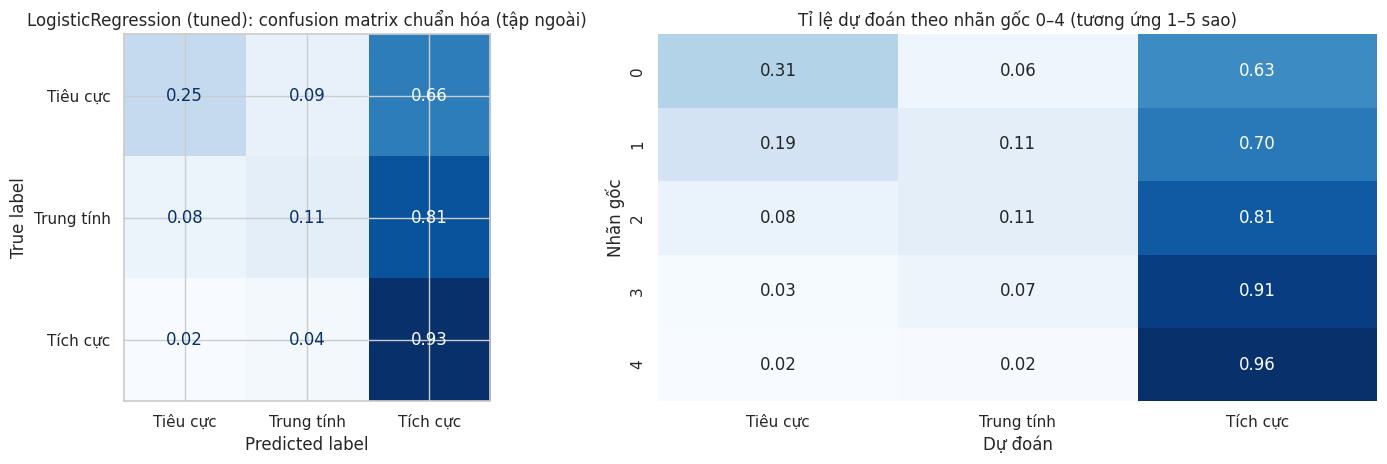

In [27]:
ext_raw, ext_path = read_jsonl_safe(EXTERNAL_FILE)
EXT_MAP = {0: 0, 1: 0, 2: 1, 3: 2, 4: 2}
ext = ext_raw.dropna(subset=['text']).copy()
ext['y'] = ext['label'].map(EXT_MAP)
X_ext = pd.DataFrame({'reviewText': ext['text'].values}).reindex(columns=BASE_COLS)
y_ext = ext['y'].values
print(f'Nguồn: {ext_path} | {len(ext):,} đánh giá | phân bố nhãn gốc: {ext["label"].value_counts().sort_index().to_dict()}')
print('Phân bố 3 lớp (tập ngoài):', {CLASS_NAMES[k]: f'{(y_ext == k).mean():.1%}' for k in CLASSES},
      '| (tập Test chính:', {CLASS_NAMES[k]: f'{(y_test == k).mean():.1%}' for k in CLASSES}, ')')

ext_pred = final_model.predict(X_ext)
share_pos = pd.Series(ext_pred == 2).groupby(ext['label'].values).mean()
print('Kiểm tra giả định — % bị dự đoán "Tích cực" theo nhãn gốc 0→4:', [f'{v:.0%}' for v in share_pos.values],
      '→ tăng đơn điệu:', bool(share_pos.is_monotonic_increasing))

ext_results = pd.DataFrame({k: evaluate(m, X_ext, y_ext) for k, m in
                            {'LogisticRegression (baseline)': models['LogisticRegression'], **candidates}.items()}).T
display(ext_results.style.format(METRIC_FMT).highlight_max(color='#c6efce', axis=0))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
ConfusionMatrixDisplay(confusion_matrix(y_ext, ext_pred, normalize='true'), display_labels=labels).plot(
    ax=axes[0], cmap='Blues', colorbar=False, values_format='.2f')
axes[0].set_title(f'{best_name}: confusion matrix chuẩn hóa (tập ngoài)')
ct = pd.crosstab(ext['label'], pd.Series(ext_pred, index=ext.index).map(CLASS_NAMES), normalize='index')[labels]
sns.heatmap(ct, annot=True, fmt='.2f', cmap='Blues', cbar=False, ax=axes[1])
axes[1].set(title='Tỉ lệ dự đoán theo nhãn gốc 0–4 (tương ứng 1–5 sao)', xlabel='Dự đoán', ylabel='Nhãn gốc')
plt.tight_layout(); plt.show()

> **Nhận xét (5,000 đánh giá ngoài, nhiều ngành hàng; 40% Tiêu cực / 20% Trung tính / 40% Tích cực):**
> - **Giả định gộp nhãn hợp lý:** tỉ lệ bị đoán "Tích cực" tăng đơn điệu theo nhãn gốc 0→4: **63%, 70%, 81%, 91%, 96%**. Tuy nhiên 63% đánh giá 1 sao bị đoán Tích cực → mô hình **kém hẳn khi đổi miền**.
> - **Hiệu năng giảm mạnh:** mô hình cuối (LogReg tuned) có F1 macro **0.389** (Accuracy 0.496, ROC-AUC 0.729), so với 0.593 trên Test. Cả 6 mô hình trong bảng đều có ROC-AUC chỉ khoảng 0.70–0.73.
> - **Xếp hạng đảo ngược:** MultinomialNB (tuned) là mô hình tốt nhất ở tập ngoài (F1 **0.517**, F1 Trung tính 0.294) dù là mô hình thấp nhất trong nhóm đã tuning ở Validation (F1 0.527) và ở Test (0.518, so với LinearSVC 0.597). Có thể vì nó dùng tiên nghiệm đều (`fit_prior=False`) nên ít bị kéo về lớp Tích cực (90% ở dữ liệu huấn luyện).
> - **Nguyên nhân có thể:** từ vựng học từ thẻ nhớ (*card, fast, space, works*) không chuyển sang ngành hàng khác; ngoài ra phân bố lớp ở tập ngoài (40/20/40) rất khác khi huấn luyện (90/3/7), nên prior của mô hình lệch.

### 4.6. Mở rộng 2 — So sánh với mô hình Transformer pretrained (zero-shot)
Để so sánh ML truyền thống với Deep Learning, nhóm dùng mô hình `cardiffnlp/twitter-roberta-base-sentiment-latest` (RoBERTa đã huấn luyện sẵn cho cảm xúc,
đúng 3 lớp negative / neutral / positive) và dự đoán **zero-shot** (không huấn luyện lại) trên tập Test.
Ô này cần internet để tải mô hình (~500 MB) và chạy mất vài phút trên CPU; nếu lỗi hoặc đặt `RUN_TRANSFORMER = False` thì tự bỏ qua, không ảnh hưởng phần còn lại.

In [28]:
RUN_TRANSFORMER = True
TRANSFORMER_NAME = 'cardiffnlp/twitter-roberta-base-sentiment-latest'
transformer_result = None

if RUN_TRANSFORMER:
    try:
        import torch
        from transformers import pipeline as hf_pipeline
        device = 0 if torch.cuda.is_available() else -1
        hf = hf_pipeline('sentiment-analysis', model=TRANSFORMER_NAME, device=device, truncation=True, max_length=128, top_k=None)
        outputs = hf(X_test['reviewText'].tolist(), batch_size=32)
        name_to_id = {'negative': 0, 'neutral': 1, 'positive': 2}
        hf_scores = np.zeros((len(outputs), 3))
        for i, out in enumerate(outputs):
            for item in out:
                hf_scores[i, name_to_id[item['label'].lower()]] = item['score']
        hf_pred = hf_scores.argmax(axis=1)
        transformer_result = {'Accuracy': accuracy_score(y_test, hf_pred),
                              'Precision': precision_score(y_test, hf_pred, average='macro', zero_division=0),
                              'Recall': recall_score(y_test, hf_pred, average='macro', zero_division=0),
                              'F1': f1_score(y_test, hf_pred, average='macro', zero_division=0),
                              'ROC-AUC': macro_auc(y_test, hf_scores),
                              'F1 Trung tính': f1_score(y_test, hf_pred, labels=[1], average='macro', zero_division=0)}
        compare = pd.DataFrame({f'{best_name} (ML truyền thống)': evaluate(final_model, X_test, y_test),
                                'RoBERTa pretrained (zero-shot)': transformer_result}).T
        display(compare.style.format(METRIC_FMT).highlight_max(color='#c6efce', axis=0))
        d_f1 = transformer_result['F1'] - evaluate(final_model, X_test, y_test)['F1']
        print(f"F1 macro: RoBERTa zero-shot = {transformer_result['F1']:.3f} | {best_name} = {evaluate(final_model, X_test, y_test)['F1']:.3f} "
              f"| chênh lệch = {d_f1:+.3f} ({'Transformer cao hơn' if d_f1 > 0 else 'ML truyền thống cao hơn'})")
        print(classification_report(y_test, hf_pred, target_names=labels, digits=3, zero_division=0))
        ConfusionMatrixDisplay(confusion_matrix(y_test, hf_pred, normalize='true'), display_labels=labels).plot(cmap='Blues', colorbar=False, values_format='.2f')
        plt.title('RoBERTa zero-shot: confusion matrix chuẩn hóa (Test)'); plt.show()
    except Exception as err_hf:
        print(f'Bỏ qua phần Transformer ({type(err_hf).__name__}: {err_hf}).')
else:
    print('RUN_TRANSFORMER = False -> bỏ qua.')

Bỏ qua phần Transformer (ModuleNotFoundError: No module named 'torch').


> **Nhận xét:** Ô trên chỉ chạy khi môi trường có `torch`, `transformers` và internet (để tải mô hình ~500 MB); nếu không thì tự bỏ qua mà không ảnh hưởng phần còn lại.
> **Bản notebook đã chạy sẵn trong repo được tạo ở môi trường không có `torch`, nên ô này in thông báo bỏ qua và chưa có số liệu RoBERTa**; vì vậy nhóm không đưa ra kết luận nào về Transformer từ bản này. Để có kết quả: `pip install torch transformers` rồi chạy lại notebook; bảng so sánh F1 macro, F1 Trung tính giữa ML truyền thống và RoBERTa sẽ tự hiện ra.

### 4.7. Demo hàm suy luận `predict_sample`
Hàm nhận **một câu đánh giá thô** (tiếng Anh), tự chạy toàn bộ pipeline (làm sạch → TF-IDF → mô hình) và trả về nhãn cùng xác suất.
Nếu mô hình cuối là LinearSVC (không có xác suất), độ tin cậy được tính bằng softmax của `decision_function` — chỉ mang tính tham khảo, chưa hiệu chỉnh.

In [29]:
def predict_sample(text, model=final_model):
    x = pd.DataFrame([{'reviewText': text}]).reindex(columns=BASE_COLS)
    scores = get_scores(model, x)[0]
    if not hasattr(model, 'predict_proba'):
        e = np.exp(scores - scores.max())
        scores = e / e.sum()
    k = int(np.argmax(scores))
    return {'Nhãn dự đoán': CLASS_NAMES[k], 'Độ tin cậy': f'{scores[k]:.1%}',
            **{f'P({CLASS_NAMES[i]})': f'{scores[i]:.1%}' for i in CLASSES}}


demo_reviews = {
    'Khen rõ ràng': 'Works perfectly in my phone, fast and easy to install. Highly recommend this card!',
    'Chê rõ ràng': 'Card stopped working after two days and I lost all my photos. Waste of money, I want a refund.',
    'Phủ định (not good)': 'This card is not good. It does not work in my tablet and it is very slow.',
    'Trung tính / lưng chừng': 'It is okay for the price. Does the job, but nothing special.',
    'Có cả ưu và nhược': 'Great speed but the card failed after a month. Not sure I would buy it again.',
    'Rất ngắn': 'Fine.',
    'Ngoài miền (tai nghe)': 'The sound quality is not good at all and the battery died quickly.',
}
display(pd.DataFrame({k: predict_sample(v) for k, v in demo_reviews.items()}).T)

,Nhãn dự đoán,Độ tin cậy,P(Tiêu cực),P(Trung tính),P(Tích cực)
Khen rõ ràng,Tích cực,98.7%,0.5%,0.8%,98.7%
Chê rõ ràng,Tiêu cực,98.5%,98.5%,0.8%,0.6%
Phủ định (not good),Tiêu cực,59.3%,59.3%,16.8%,23.9%
Trung tính / lưng chừng,Tích cực,79.9%,4.1%,16.1%,79.9%
Có cả ưu và nhược,Tiêu cực,75.1%,75.1%,15.1%,9.8%
Rất ngắn,Tích cực,76.4%,11.7%,11.8%,76.4%
Ngoài miền (tai nghe),Tích cực,52.8%,44.4%,2.8%,52.8%


### 4.8. Kết luận, hạn chế và hướng phát triển

**Kết quả chính (mô hình cuối: Logistic Regression, `C=3`, `class_weight='balanced'`, TF-IDF 5,000 đặc trưng, 1–2-gram):**
- Test: Accuracy **0.919**, F1 macro **0.593**, ROC-AUC macro **0.884**; tốt hơn Dummy (F1 0.317) và LogReg mặc định (F1 0.458).
- Câu hỏi 1 (từ phân biệt): Tiêu cực ↔ từ hỏng hóc/đòi hoàn tiền và phủ định (*died, failed, refund, not recommend*); Tích cực ↔ *great, works, fast, no problems*; Trung tính không có từ đặc trưng rõ.
- Câu hỏi 2 (mất cân bằng ~90%): `class_weight='balanced'` tăng số đánh giá Tiêu cực bắt được từ **13 lên 37 trong 48** (và F1 macro từ 0.458 lên 0.593), đổi lại số báo nhầm vào lớp Tiêu cực tăng từ 2 lên 27. Với lớp Trung tính chỉ bắt được **3/22**.
- Meta-features (độ dài, số dấu `!`, bình chọn...) **không giúp** F1 macro (0.620 → 0.619).

**Hạn chế:**
- **Lớp Trung tính chỉ có 142 mẫu** (22 mẫu ở Test): mọi con số của lớp này có sai số rất lớn.
- Nhãn suy ra từ điểm sao nên có nhiễu; mô hình túi từ không hiểu ngữ cảnh/mỉa mai/ý vừa khen vừa chê.
- **Không tổng quát hóa sang ngành hàng khác:** F1 macro giảm từ 0.593 (Test) xuống 0.389 (tập ngoài); dữ liệu huấn luyện chủ yếu là thẻ nhớ.
- Mục 4.6 (Transformer) chưa có số liệu trong bản đã chạy do môi trường không có `torch`.

**Hướng phát triển:** thu thập thêm đánh giá Trung tính; thử SMOTE/tăng cường dữ liệu; tinh chỉnh ngưỡng quyết định theo từng lớp; dùng embedding hoặc fine-tune Transformer; huấn luyện trên dữ liệu đa ngành hàng.